# Práctica 4: Similitud Léxica y Semántica

## Introducción Teórica y Objetivos

El objetivo de la práctica es entrenar y evaluar modelos de **embeddings distribucionales (estáticos)** y compararlos con **embeddings contextuales** para tareas de similitud semántica en español.

Los **Word Embeddings** permiten representar palabras como vectores numéricos basándose en su contexto. Siguiendo la **Hipótesis Distribucional** de Firth (1957): *"Conocerás una palabra por las compañías que mantiene"*, las palabras que aparecen en contextos similares tenderán a tener significados similares.

### Tipos de embeddings

**Estáticos (Word2Vec, fastText):** Cada palabra tiene siempre el mismo vector independientemente del contexto. Word2Vec (Mikolov, Google 2013) propone dos arquitecturas:
- **CBOW**: predice la palabra central a partir de las palabras de contexto.
- **Skip-gram**: predice las palabras de contexto a partir de la palabra central.



**fastText** (Facebook, 2016) mejora Word2Vec representando cada palabra como la suma de los embeddings de sus n-gramas de caracteres, permitiendo gestionar palabras fuera del vocabulario (OOV).

**Contextuales (BERT):** Generan representaciones dinámicas basadas en la oración completa, resolviendo problemas como la polisemia.

### Evaluación
- **Intrínseca (Multi-SimLex)**: Calculamos la similitud coseno entre los vectores y la comparamos con las puntuaciones humanas mediante la **correlación de Spearman**.
- **Extrínseca (Spanish STS)**: Calculamos la similitud semántica de pares de frases y evaluamos con la **correlación de Pearson**.



### Datasets y metodología de evaluación

Para evaluar la calidad de los vectores generados, utilizaremos dos enfoques complementarios:

1. **Evaluación intrínseca (Multi-SimLex ES)**  
   - **Descripción:** Conjunto de pares de palabras con puntuaciones de similitud asignadas por evaluadores humanos.  
   - **Objetivo:** Analizar hasta qué punto los vectores capturan relaciones semánticas directas entre palabras.  
   - **Métrica:** **Correlación de Spearman ($\rho$)**. Se utiliza para medir la relación monótona entre las distancias producidas por el modelo y las puntuaciones humanas. Esta métrica es menos sensible a valores atípicos que la correlación de Pearson.

2.  **Evaluación Extrínseca (Spanish STS):**
    * **Descripción:** Tarea de *Semantic Textual Similarity* con pares de frases.
    * **Objetivo:** Evaluar la capacidad de los embeddings para representar unidades de significado mayores (frases) mediante técnicas de agregación o modelos secuenciales.
    * **Métrica:** **Correlación de Pearson ($r$)**. Mide la relación lineal entre la predicción del modelo y el "gold standard", estándar en tareas de regresión para STS.

3. **Corpus de entrenamiento (raw.es.tgz)**  
   - **Descripción:** Corpus extraído de la Wikipedia en español en formato raw.  
   - **Uso:** Entrenamiento desde cero de modelos de embeddings estáticos (Word2Vec/fastText) para analizar el impacto del tamaño del corpus y la dimensionalidad del espacio vectorial.

| Dataset | Tarea | Métrica oficial | Tipo de embedding |
|--------|------|----------------|------------------|
| **Multi-SimLex** | Similitud léxica | Spearman | Estáticos |
| **Spanish STS** | Similitud de frases | Pearson | Estáticos (agregados) y contextuales |
| **Wikipedia ES** | Entrenamiento | N/A | Pre-entrenamiento |

## 0. Setup

In [2]:
# Instalar dependencias si hace falta
#%pip install pandas scipy datasets tqdm gensim torch sentence-transformers scikit-learn transformers matplotlib seaborn

import pandas as pd
import numpy as np
import os
import seaborn as sns
import re
from pathlib import Path
import types
from itertools import product
from scipy.stats import spearmanr, pearsonr
from datasets import load_dataset
from gensim.models import Word2Vec, FastText as GensimFastText
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import warnings
import json
import random
from joblib import Parallel, delayed
from gensim.models import KeyedVectors
warnings.filterwarnings('ignore')
import unicodedata
from nltk.corpus import stopwords
import gc

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    print("CUDA no disponible — usando CPU (puede ser lento)")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

d:\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de Datasets

### Columnas del dataset Multi-SimLex (ES)

| Columna | Descripción |
|---|---|
| **PAIR_ID** | Identificador único del par de palabras en el dataset. |
| **SPA_W1** | Primera palabra del par. |
| **SPA_W2** | Segunda palabra del par. |
| **SPA_AVG** | Puntuación media de similitud semántica asignada por varios anotadores humanos. Cuanto mayor es el valor, más similares se consideran las dos palabras. En este dataset los valores observados van aproximadamente de **0.0** a **5.9**. |

In [3]:
# ============================================================
# DATASET 1 — Multi-SimLex
# ============================================================

os.system("wget -O SPA.csv https://web.archive.org/web/20231020014354/https://multisimlex.com/data/SPA.csv")

spa = pd.read_csv("SPA.csv")

annotator_cols = [c for c in spa.columns if c.startswith('Annotator')]
spa['SPA_AVG'] = spa[annotator_cols].mean(axis=1)

# Guardamos también las columnas de anotadores para el análisis posterior
multi_simlex = spa[['ID', 'Word 1', 'Word 2'] + annotator_cols + ['SPA_AVG']].copy()
multi_simlex.columns = ['PAIR_ID', 'SPA_W1', 'SPA_W2'] + annotator_cols + ['SPA_AVG']

print(f"Multi-SimLex (ES) — {len(multi_simlex)} pares de palabras")
print(f"Columnas de anotadores: {annotator_cols}")
multi_simlex.head()

Multi-SimLex (ES) — 1888 pares de palabras
Columnas de anotadores: ['Annotator 1', 'Annotator 2', 'Annotator 3', 'Annotator 4', 'Annotator 5', 'Annotator 6', 'Annotator 7', 'Annotator 8', 'Annotator 9', 'Annotator 10']


,PAIR_ID,SPA_W1,SPA_W2,Annotator 1,Annotator 2,Annotator 3,Annotator 4,Annotator 5,Annotator 6,Annotator 7,Annotator 8,Annotator 9,Annotator 10,SPA_AVG
0,1,brazo,músculo,1,1,5,0,0,0,2,1,2,2,1.4
1,2,democracia,monarquía,0,0,3,0,0,0,2,1,3,4,1.3
2,3,tejado,techo,5,5,6,4,5,3,4,4,6,6,4.8
3,4,amigo,profesor,0,0,1,0,0,0,2,0,1,0,0.4
4,5,mano,pie,1,0,3,0,0,0,2,1,3,1,1.1


In [4]:
# vemos los valores mínimo y máximo de las puntuaciones
min_score = multi_simlex['SPA_AVG'].min()
max_score = multi_simlex['SPA_AVG'].max()

print("Valor mínimo:", min_score)
print("Valor máximo:", max_score)

Valor mínimo: 0.0
Valor máximo: 5.9


### Columnas del dataset Spanish STS

| Columna | Descripción |
|---|---|
| **id** | Identificador único del par de frases. |
| **sentence1** | Primera frase del par. |
| **sentence2** | Segunda frase del par. |
| **score** | Puntuación de similitud semántica asignada por anotadores humanos. Cuanto mayor es el valor, más similares son las dos frases. |

In [5]:
# ============================================================
# DATASET 2 — Spanish STS (PlanTL-GOB-ES/sts-es)
# Avaluación extrínseca · Métrica: correlación de Pearson
# ============================================================
sts = load_dataset("PlanTL-GOB-ES/sts-es")

train_df = sts["train"].to_pandas().rename(columns={"label": "score"})
dev_df   = sts["validation"].to_pandas().rename(columns={"label": "score"})
# Nota: nos fijamos que el split se llama "validation" en HuggingFace, no "dev" como indica el enunciado
test_df  = sts["test"].to_pandas().rename(columns={"label": "score"})

print(f"Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")
print(train_df.head())

Using the latest cached version of the dataset since PlanTL-GOB-ES/sts-es couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'STS' at C:\Users\lihao\.cache\huggingface\datasets\PlanTL-GOB-ES___sts-es\STS\1.0.0\0912bb6c9393c76d62a7c5ee81c4c817ff47c9f4 (last modified on Thu Apr 16 20:26:41 2026).


Train: 1320 | Dev: 77 | Test: 155
  id                                          sentence1  \
0  0  Según el sondeo, 87% de los católicos cree que...   
1  1  La psicología explora conceptos como la percep...   
2  2  La tradición comenzó en el siglo IV, pero la m...   
3  3  "Maria Anna Schwegelin" (? - 1781 en la cárcel...   
4  4  Su identidad la había revelado durante el viaj...   

                                           sentence2  score  
0  El 87% de los católicos del mundo aprobaron el...   3.75  
1  La "psicología básica" es la parte de la psico...   2.80  
2  La tradición de erigir piedras con inscripcion...   2.40  
3  Te entregamos, Anna Schwegelin, al verdugo par...   2.20  
4  La información fue suministrada por el pescado...   2.20  


### Corpus de Wikipedia en español (`raw_es`)

Este corpus se utilizará para entrenar los modelos de embeddings (**Word2Vec** y **fastText**). El corpus está dividido en múltiples archivos de texto dentro de la carpeta `raw_es` y cada archivo contiene una parte del texto extraído de Wikipedia en español.

En total se han encontrado **57 archivos** dentro del corpus.

In [6]:
# ============================================================
# DATASET 3 — Corpus Wikipedia en español
# ============================================================
corpus_dir   = "raw_es"
corpus_files = sorted(os.listdir(corpus_dir))

print(f"Total archivos encontrados: {len(corpus_files)}")
print(corpus_files[:5])

Total archivos encontrados: 57
['spanishText_10000_15000', 'spanishText_110000_115000', 'spanishText_120000_125000', 'spanishText_15000_20000', 'spanishText_180000_185000']


## 2. Preprocesamiento de *raw_es*

Es necesario realizar un preprocesamiento sobre el corpus *raw_es* para eliminar elementos 
que no aportan información: etiquetas **`<doc ...>`/`</doc>`**, **`ENDOFARTICLE`** y **URLs**.

También aplicaremos preprocesamiento básico: 

1. **Normalización Unicode (NFKC):** Permite unificar diferentes representaciones Unicode de un mismo carácter. Por ejemplo, una letra como *ñ* puede
aparecer como un carácter precompuesto (`ñ`) o como la secuencia `n` seguida de una marca diacrítica (`◌̃`). Sin normalización, el modelo
podría tratar ambas formas como tokens distintos, a pesar de ser visualmente equivalentes.

2. **Conversión a minúsculas:** Reduce el tamaño del vocabulario al unificar variantes como *Casa* y *casa*, permitiendo que el modelo disponga de más evidencia estadística para cada término.

3. **Eliminación de ruido estructural (Regex):**
   - **URLs y etiquetas HTML:** Se eliminan mediante expresiones regulares, ya que las direcciones web y etiquetas como `<doc>` no aportan información semántica relevante para la construcción del espacio vectorial.
   - **Marcas del corpus de Wikipedia:** Se filtra el token `ENDOFARTICLE`, utilizado como marcador estructural en el formato del corpus de Wikipedia.

4. **Limpieza de caracteres no alfabéticos:** Utilizamos el patrón `[^a-záéíóúüñ\s]` para conservar únicamente letras y espacios. Este filtrado elimina puntuación, números y otros símbolos que suelen introducir ruido en embeddings de propósito general.

5. **Tokenización simple:** Se aplica `.split()` para separar las palabras por espacios en blanco. Dado que la puntuación ha sido eliminada en pasos previos, este procedimiento funciona como una tokenización básica a nivel de palabra (*word-level tokenization*).


Respecto a las **stopwords**, la literatura no es concluyente:

- La implementación de Gensim ya realiza *subsampling* automático de palabras frecuentes 
  (parámetro `sample=0.001`), por lo que las stopwords ya reciben menos peso durante el 
  entrenamiento sin necesidad de eliminarlas explícitamente.

- Por otro lado, las stopwords pueden ser útiles para asociar palabras relacionadas a través 
  del contexto sintáctico. Por ejemplo, nombres de ciudades pueden aparecer juntos no solo 
  por verbos como *"ir"* o *"viajar"*, sino también por preposiciones como *"a"*, *"desde"* 
  o *"en"* — relaciones que se perderían al eliminarlas.

- Además, el español tiene una morfología más rica que el inglés (artículos, preposiciones 
  contractas, pronombres clíticos...), por lo que eliminar stopwords puede suponer una 
  pérdida de contexto mayor que en otras lenguas.

Por este motivo, entrenaremos **dos modelos** para cada configuración (con y sin stopwords) 
y evaluaremos empíricamente cuál obtiene mejores resultados en Multi-SimLex y Spanish STS.

**Referencias**:
- Trideep Rath (2016). [*Stopword removing when using the word2vec*](https://stackoverflow.com/questions/34721984/stopword-removing-when-using-the-word2vec). Stack Overflow.
- Jindřich (2020). [*Text preprocessing for text classification using fastText*](https://stackoverflow.com/questions/62244474/text-preprocessing-for-text-classification-using-fasttext). Stack Overflow.

In [7]:
STOPWORDS = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    texto = unicodedata.normalize("NFKC", texto)
    texto = texto.lower()
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)
    texto = re.sub(r'<[^>]+>', ' ', texto)
    texto = re.sub(r'endofarticle\.?', ' ', texto, flags=re.IGNORECASE)
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def preprocesar_linea(linea, eliminar_stopwords=True):
    linea = linea.strip()
    if not linea:
        return []
    texto = limpiar_texto(linea)
    palabras = texto.split()
    if eliminar_stopwords:
        palabras = [p for p in palabras if p and p not in STOPWORDS]
    else:
        palabras = [p for p in palabras if p]
    return palabras

class CorpusFactory:
    """
    Iterador re-entrante sobre el corpus raw_es.
    Gensim necesita dos pasadas (build_vocab + train),
    por eso cada llamada a __iter__ genera un iterador nuevo.
    """
    def __init__(self, directorio, archivos, eliminar_stopwords=True, min_len=5):
        self.directorio        = directorio
        self.archivos          = archivos
        self.eliminar_stopwords = eliminar_stopwords
        self.min_len           = min_len

    def __iter__(self):
        for nombre_archivo in self.archivos:
            ruta = os.path.join(self.directorio, nombre_archivo)
            with open(ruta, "r", encoding="latin-1", errors="ignore") as f:
                for linea in f:
                    palabras = preprocesar_linea(linea, self.eliminar_stopwords)
                    if len(palabras) >= self.min_len:
                        yield palabras

In [8]:
corpus_con_sw = CorpusFactory(corpus_dir, corpus_files, eliminar_stopwords=False)
corpus_sin_sw = CorpusFactory(corpus_dir, corpus_files, eliminar_stopwords=True)

N = 20 

# Verificación visual
print("-- CON stopwords --")
for i, frase in enumerate(corpus_con_sw):
    print(f"  [{i+1}] {frase[:10]}")
    if i == N - 1: break

print("\n-- SIN stopwords --")
for i, frase in enumerate(corpus_sin_sw):
    print(f"  [{i+1}] {frase[:10]}")
    if i == N - 1: break

-- CON stopwords --
  [1] ['fulgencio', 'de', 'écija', 'santo', 'español']
  [2] ['erquinoaldo', 'mayordomo', 'franco', 'de', 'palacio', 'de', 'neustria']
  [3] ['egilona', 'última', 'reina', 'visigoda', 'de', 'hispania']
  [4] ['fin', 'del', 'califato', 'perfecto', 'los', 'omeyas', 'en', 'el', 'poder', 'califato']
  [5] ['los', 'omeyas', 'acceden', 'al', 'califato']
  [6] ['mundo', 'islámico', 'alí', 'murió', 'traicionado', 'por', 'los', 'suyos', 'y', 'asesinado']
  [7] ['un', 'monje', 'anónimo', 'realiza', 'la', 'primera', 'escalada', 'al', 'monte', 'fuji']
  [8] ['este', 'artículo', 'trata', 'sobre', 'el', 'año', 'd', 'c', 'para', 'otros']
  [9] ['la', 'península', 'de', 'corea', 'es', 'unificada', 'por', 'vez', 'primera', 'en']
  [10] ['de', 'septiembre', 'constante', 'ii', 'emperador', 'bizantino']
  [11] ['chilperico', 'ii', 'rey', 'franco', 'merovingio']
  [12] ['brahmagupta', 'matemático', 'y', 'astrónomo', 'indio']
  [13] ['de', 'septiembre', 'wamba', 'fue', 'elegido', 'rey', 

## 3. Funciones de Evaluación

### Evaluación intrínseca (Multi-SimLex)

Para cada par de palabras, obtenemos sus vectores y calculamos la **similitud coseno**. Posteriormente, calculamos la **correlación de Spearman** entre las similitudes predichas y las puntuaciones humanas.

Tal como se remarcó en las sesiones de laboratorio, es interesante evaluar la **puntuación de cada anotador** individualmente y realizar el promedio, lo que refleja mejor la variabilidad humana frente a una única media agregada.

Las palabras fuera del vocabulario (OOV, *Out-Of-Vocabulary*) se descartan del cálculo de la correlación. En este aspecto, **fastText** ofrece una ventaja competitiva al gestionar las OOV mediante el uso de n-gramas de caracteres.

In [9]:
def cosine_sim(v1, v2):
    """Similitud coseno entre dos vectores."""
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    return float(np.dot(v1, v2) / (n1 * n2))

def get_vector(model, word):
    """Obtiene el vector de una palabra (compatible con Word2Vec y FastText de gensim)."""
    try:
        return model.wv[word]
    except KeyError:
        return None

def intrinsic_eval(model, df, annotator_cols):
    """
    Evaluación intrínseca sobre Multi-SimLex.
    Retorna:
      - spearman_avg: correlación de Spearman respecto a SPA_AVG
      - spearman_annotators: media de las correlaciones por anotador
      - oov_rate: proporción de pares con palabras fuera del vocabulario (OOV)
    """
    sims, golds_avg, golds_annot = [], [], [[] for _ in annotator_cols]
    oov_count = 0

    for _, row in df.iterrows():
        v1 = get_vector(model, row['SPA_W1'])
        v2 = get_vector(model, row['SPA_W2'])
        if v1 is None or v2 is None:
            oov_count += 1
            continue
        sims.append(cosine_sim(v1, v2))
        golds_avg.append(row['SPA_AVG'])
        for i, col in enumerate(annotator_cols):
            golds_annot[i].append(row[col])

    if len(sims) < 2:
        return 0.0, 0.0, 1.0

    spearman_avg = spearmanr(sims, golds_avg).statistic

    # Correlación por anotador (puntuación de cada anotador individualmente)
    corrs_annot = [spearmanr(sims, g).statistic for g in golds_annot if len(g) > 1]
    spearman_annotators = float(np.mean(corrs_annot))

    oov_rate = oov_count / len(df)
    return spearman_avg, spearman_annotators, oov_rate

def truncar_vectores(model, new_dim):
    """
    Trunca los vectores del model a 'new_dim' dimensiones.
    """
    from gensim.models import KeyedVectors
    kv_trunc = KeyedVectors(vector_size=new_dim)
    words = list(model.wv.index_to_key)
    vectors = model.wv.vectors[:, :new_dim]
    kv_trunc.add_vectors(words, vectors)
    
    # Wrapper para mantener la interfaz .wv
    class ModelWrapper:
        def __init__(self, kv): self.wv = kv
    return ModelWrapper(kv_trunc)

print("Funciones de evaluación intrínseca definidas")

Funciones de evaluación intrínseca definidas


## 4. Word2Vec: CBOW y Skip-gram

Entrenamos modelos Word2Vec con ambas arquitecturas. Tal como explica la teoría:
- **CBOW** (*Continuous Bag-of-Words*): predice la palabra central a partir de las palabras de contexto.
- **Skip-gram**: predice las palabras de contexto a partir de la palabra central.

Experimentamos con:
1. Presencia/ausencia de stopwords.
2. Dimensiones del vector (100 vs 300) + truncado a 100d.
3. Cantidad de corpus (efecto del tamaño del corpus).

> **Nota de implementación**: Nunca debemos usar el modelo de Word2Vec directamente para pasarlo a la capa de embeddings de la red neuronal sin restringir el vocabulario. Es necesario construir una matriz de embeddings específica con el vocabulario del corpus de entrenamiento para optimizar la memoria y el rendimiento.

In [ ]:
# Wrapper ligero para modelos guardados como KeyedVectors
class ModeloLigero:
    """Preserva la interfaz .wv y los hiperparámetros al cargar desde .bin"""
    def __init__(self, wv, vector_size, window, min_count, epochs):
        self.wv          = wv
        self.vector_size = vector_size
        self.window      = window
        self.min_count   = min_count
        self.epochs      = epochs

# Parámetros
N_ARCHIVOS_MUESTRA     = 5
N_ARCHIVOS_FINAL       = 20
EXPERIMENTO_N_ARCHIVOS = [5, 10, 20, len(corpus_files)]

param_grid = {
    'vector_size': [25, 50, 100, 300],
    'window':      [3, 5],
    'min_count':   [5, 10],
    'epochs':      [5, 10],
}
claves        = list(param_grid.keys())
combinaciones = list(product(*param_grid.values()))

In [11]:
# Setup común
modelos_w2v = {}

def entrenar_o_cargar(nombre_arq, sg, eliminar_sw, sufijo_sw):
    nombre_modelo = f"w2v_{nombre_arq.lower().replace('-','_')}_{sufijo_sw}"
    nombre_bin    = nombre_modelo + '.bin'
    nombre_json   = nombre_modelo + '.json'

    print(f"\n{'='*60}")
    print(f"  {nombre_arq} — {sufijo_sw.replace('_',' ')}")
    print(f"{'='*60}")

    # Carga si ya existe
    if os.path.exists(nombre_bin) and os.path.exists(nombre_json):
        print(f"  Cargando modelo existente: {nombre_bin}...")
        wv = KeyedVectors.load_word2vec_format(nombre_bin, binary=True)
        with open(nombre_json) as f:
            hp = json.load(f)
        modelo = ModeloLigero(wv, **hp)
        print(f"  Cargado — vocabulario: {len(modelo.wv):,} palabras")

    elif 'corpus_files' in globals():
        # Cachear ambos corpus
        print("  Cargando corpus en memoria...")
        corpus_muestra = list(
            CorpusFactory(corpus_dir, corpus_files[:N_ARCHIVOS_MUESTRA],
                          eliminar_stopwords=eliminar_sw)
        )
        corpus_final = list(
            CorpusFactory(corpus_dir, corpus_files[:N_ARCHIVOS_FINAL],
                          eliminar_stopwords=eliminar_sw)
        )

        # Grid search
        print(f"  Grid search ({len(combinaciones)} combinaciones)...")
        resultados, mejor_score, mejor_modelo_gensim = [], -np.inf, None
        for i, combo in enumerate(combinaciones):
            params = dict(zip(claves, combo))
            m = Word2Vec(
                sentences=corpus_muestra,
                vector_size=params['vector_size'],
                window=params['window'],
                min_count=params['min_count'],
                sg=sg, workers=4, epochs=params['epochs'], seed=SEED
            )
            sp_avg, sp_ann, oov = intrinsic_eval(m, multi_simlex, annotator_cols)
            resultados.append({**params, 'spearman_avg': sp_avg,
                               'spearman_ann': sp_ann, 'oov': oov})
            print(f"  [{i+1}/{len(combinaciones)}] {params} -> Spearman avg: {sp_avg:.4f}")
            if sp_avg > mejor_score:
                mejor_score, mejor_modelo_gensim = sp_avg, m

        df_res = pd.DataFrame(resultados).sort_values('spearman_avg', ascending=False)
        print(f"\n  Mejores hiperparámetros:\n{df_res.iloc[0].to_string()}")

        # Ampliar con más datos
        print(f"\n  Ampliando a {N_ARCHIVOS_FINAL} archivos...")
        mejor_modelo_gensim.build_vocab(corpus_final, update=True)
        mejor_modelo_gensim.train(corpus_final,
                                  total_examples=len(corpus_final),
                                  epochs=mejor_modelo_gensim.epochs)

        # Guardado
        mejor_modelo_gensim.wv.save_word2vec_format(nombre_bin, binary=True)
        with open(nombre_json, 'w') as f:
            json.dump({
                'vector_size': mejor_modelo_gensim.vector_size,
                'window':      mejor_modelo_gensim.window,
                'min_count':   mejor_modelo_gensim.min_count,
                'epochs':      mejor_modelo_gensim.epochs,
            }, f)
        print(f"  Guardado -> '{nombre_bin}' + '{nombre_json}'")

        modelo = ModeloLigero(
            wv=mejor_modelo_gensim.wv,
            vector_size=mejor_modelo_gensim.vector_size,
            window=mejor_modelo_gensim.window,
            min_count=mejor_modelo_gensim.min_count,
            epochs=mejor_modelo_gensim.epochs,
        )
    else:
        print("  AVISO: Corpus no disponible. Saltando."); return None

    # Evaluación final
    sp_avg, sp_ann, oov = intrinsic_eval(modelo, multi_simlex, annotator_cols)
    print(f"  Spearman (SPA_AVG):             {sp_avg:.4f}")
    print(f"  Spearman (por anotador, media): {sp_ann:.4f}")
    print(f"  OOV rate:                       {oov:.2%}")

    return modelo

print("Setup completado")

Setup completado


In [12]:
# CBOW sin stopwords
modelos_w2v['CBOW_sin_sw'] = entrenar_o_cargar(
    nombre_arq='CBOW', sg=0, eliminar_sw=True, sufijo_sw='sin_sw'
)


  CBOW — sin sw
  Cargando corpus en memoria...
  Grid search (16 combinaciones)...
  [1/16] {'vector_size': 100, 'window': 3, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.2627
  [2/16] {'vector_size': 100, 'window': 3, 'min_count': 5, 'epochs': 10} -> Spearman avg: 0.3034
  [3/16] {'vector_size': 100, 'window': 3, 'min_count': 10, 'epochs': 5} -> Spearman avg: 0.2600
  [4/16] {'vector_size': 100, 'window': 3, 'min_count': 10, 'epochs': 10} -> Spearman avg: 0.3092
  [5/16] {'vector_size': 100, 'window': 5, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.2692
  [6/16] {'vector_size': 100, 'window': 5, 'min_count': 5, 'epochs': 10} -> Spearman avg: 0.3209
  [7/16] {'vector_size': 100, 'window': 5, 'min_count': 10, 'epochs': 5} -> Spearman avg: 0.2805
  [8/16] {'vector_size': 100, 'window': 5, 'min_count': 10, 'epochs': 10} -> Spearman avg: 0.3172
  [9/16] {'vector_size': 300, 'window': 3, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.2556
  [10/16] {'vector_size': 300, 'window': 3,

In [13]:
# CBOW con stopwords
modelos_w2v['CBOW_con_sw'] = entrenar_o_cargar(
    nombre_arq='CBOW', sg=0, eliminar_sw=False, sufijo_sw='con_sw'
)


  CBOW — con sw
  Cargando corpus en memoria...
  Grid search (16 combinaciones)...
  [1/16] {'vector_size': 100, 'window': 3, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.2420
  [2/16] {'vector_size': 100, 'window': 3, 'min_count': 5, 'epochs': 10} -> Spearman avg: 0.2915
  [3/16] {'vector_size': 100, 'window': 3, 'min_count': 10, 'epochs': 5} -> Spearman avg: 0.2480
  [4/16] {'vector_size': 100, 'window': 3, 'min_count': 10, 'epochs': 10} -> Spearman avg: 0.2841
  [5/16] {'vector_size': 100, 'window': 5, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.2689
  [6/16] {'vector_size': 100, 'window': 5, 'min_count': 5, 'epochs': 10} -> Spearman avg: 0.3054
  [7/16] {'vector_size': 100, 'window': 5, 'min_count': 10, 'epochs': 5} -> Spearman avg: 0.2707
  [8/16] {'vector_size': 100, 'window': 5, 'min_count': 10, 'epochs': 10} -> Spearman avg: 0.2998
  [9/16] {'vector_size': 300, 'window': 3, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.2503
  [10/16] {'vector_size': 300, 'window': 3,

In [14]:
# Skip-gram sin stopwords
modelos_w2v['Skip-gram_sin_sw'] = entrenar_o_cargar(
    nombre_arq='Skip-gram', sg=1, eliminar_sw=True, sufijo_sw='sin_sw'
)


  Skip-gram — sin sw
  Cargando corpus en memoria...
  Grid search (16 combinaciones)...
  [1/16] {'vector_size': 100, 'window': 3, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.2905
  [2/16] {'vector_size': 100, 'window': 3, 'min_count': 5, 'epochs': 10} -> Spearman avg: 0.3556
  [3/16] {'vector_size': 100, 'window': 3, 'min_count': 10, 'epochs': 5} -> Spearman avg: 0.3008
  [4/16] {'vector_size': 100, 'window': 3, 'min_count': 10, 'epochs': 10} -> Spearman avg: 0.3560
  [5/16] {'vector_size': 100, 'window': 5, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.3212
  [6/16] {'vector_size': 100, 'window': 5, 'min_count': 5, 'epochs': 10} -> Spearman avg: 0.3683
  [7/16] {'vector_size': 100, 'window': 5, 'min_count': 10, 'epochs': 5} -> Spearman avg: 0.3296
  [8/16] {'vector_size': 100, 'window': 5, 'min_count': 10, 'epochs': 10} -> Spearman avg: 0.3723
  [9/16] {'vector_size': 300, 'window': 3, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.2562
  [10/16] {'vector_size': 300, 'window

In [16]:
# Skip-gram con stopwords
modelos_w2v['Skip-gram_con_sw'] = entrenar_o_cargar(
    nombre_arq='Skip-gram', sg=1, eliminar_sw=False, sufijo_sw='con_sw'
)


  Skip-gram — con sw
  Cargando corpus en memoria...
  Grid search (16 combinaciones)...
  [1/16] {'vector_size': 100, 'window': 3, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.2824
  [2/16] {'vector_size': 100, 'window': 3, 'min_count': 5, 'epochs': 10} -> Spearman avg: 0.3501
  [3/16] {'vector_size': 100, 'window': 3, 'min_count': 10, 'epochs': 5} -> Spearman avg: 0.2942
  [4/16] {'vector_size': 100, 'window': 3, 'min_count': 10, 'epochs': 10} -> Spearman avg: 0.3413
  [5/16] {'vector_size': 100, 'window': 5, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.3142
  [6/16] {'vector_size': 100, 'window': 5, 'min_count': 5, 'epochs': 10} -> Spearman avg: 0.3623
  [7/16] {'vector_size': 100, 'window': 5, 'min_count': 10, 'epochs': 5} -> Spearman avg: 0.3244
  [8/16] {'vector_size': 100, 'window': 5, 'min_count': 10, 'epochs': 10} -> Spearman avg: 0.3681
  [9/16] {'vector_size': 300, 'window': 3, 'min_count': 5, 'epochs': 5} -> Spearman avg: 0.2538
  [10/16] {'vector_size': 300, 'window

KeyboardInterrupt: 

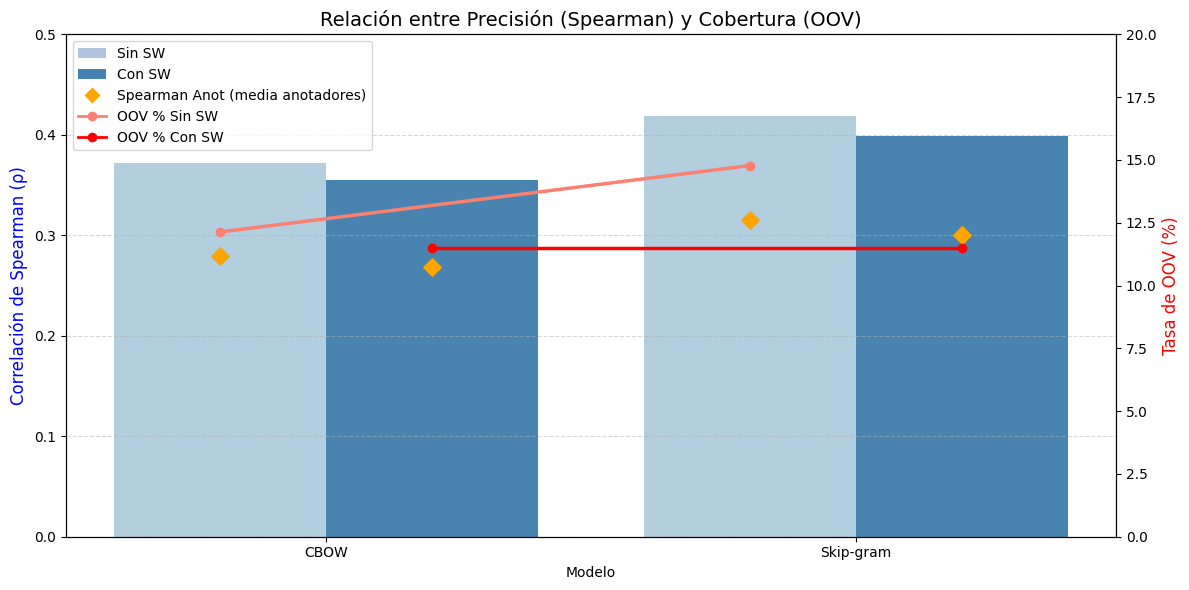

In [16]:
# 1. Recopilación dinámica de datos
datos_completos = []
for nombre, modelo in modelos_w2v.items():
    sp_avg, sp_ann, oov = intrinsic_eval(modelo, multi_simlex, annotator_cols)
    arquitectura = nombre.split('_')[0]
    sw = "Sin SW" if "sin_sw" in nombre else "Con SW"
    
    datos_completos.append({
        'Modelo': arquitectura,
        'Config': sw,
        'Spearman AVG': sp_avg,
        'Spearman Anot': sp_ann,
        'OOV %': oov * 100
    })
df_plot = pd.DataFrame(datos_completos)

# 2. Gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

modelos_orden = ['CBOW', 'Skip-gram']
configs_orden = ['Sin SW', 'Con SW']
offsets = [-0.2, 0.2]

# --- Barras Spearman AVG ---
sns.barplot(data=df_plot, x='Modelo', y='Spearman AVG', hue='Config',
            palette='Blues', ax=ax1, order=modelos_orden)

# --- Diamantes Spearman Anot ---
for config, offset in zip(configs_orden, offsets):
    subset = df_plot[df_plot['Config'] == config].set_index('Modelo')
    x_pos = [modelos_orden.index(m) + offset for m in modelos_orden]
    y_vals = [subset.loc[m, 'Spearman Anot'] for m in modelos_orden]
    ax1.scatter(x_pos, y_vals, marker='D', s=80, color='orange', zorder=5)

ax1.set_ylabel('Correlación de Spearman (ρ)', fontsize=12, color='blue')
ax1.set_ylim(0, 0.5)

# --- Líneas OOV ---
ax2 = ax1.twinx()
colors_oov = {'Sin SW': 'salmon', 'Con SW': 'red'}

for config, offset in zip(configs_orden, offsets):
    subset = df_plot[df_plot['Config'] == config].set_index('Modelo')
    x_pos = [i + offset for i in range(len(modelos_orden))]
    y_vals = [subset.loc[m, 'OOV %'] for m in modelos_orden]
    ax2.plot(x_pos, y_vals, marker='o', color=colors_oov[config], linewidth=2.5, zorder=4)

ax2.set_ylabel('Tasa de OOV (%)', fontsize=12, color='red')
ax2.set_ylim(0, 20)

# --- Leyenda ---
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='lightsteelblue', label='Sin SW'),
    Patch(facecolor='steelblue', label='Con SW'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='orange',
           markersize=9, label='Spearman Anot (media anotadores)'),
    Line2D([0], [0], color='salmon', linewidth=2, marker='o', label='OOV % Sin SW'),
    Line2D([0], [0], color='red',    linewidth=2, marker='o', label='OOV % Con SW'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=10)

ax1.set_xticks(range(len(modelos_orden)))
ax1.set_xticklabels(modelos_orden)
ax1.set_xlabel('Modelo')
plt.title('Relación entre Precisión (Spearman) y Cobertura (OOV)', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Análisis de la Evaluación Intrínseca (Multi-SimLex)
El gráfico obtenido representa el compromiso (*trade-off*) entre la calidad de las representaciones semánticas y la cobertura del vocabulario del modelo. A continuación, se detallan las conclusiones principales:

#### 1. Superioridad de Skip-gram sobre CBOW
* **Resultado:** En todas las configuraciones, **Skip-gram** supera consistentemente a CBOW en la correlación de Spearman.
* **Justificación:** Tal como se estudia en la literatura de Word2Vec, Skip-gram es más robusto para representar palabras poco frecuentes y capturar relaciones semánticas complejas, ya que su objetivo es predecir el contexto a partir de una palabra central. CBOW, al promediar los vectores del contexto, tiende a generar representaciones más "suaves" que benefician tareas sintácticas pero pierden precisión en similitud pura.

#### 2. El impacto del filtrado de Stopwords (SW)
* **Mejora en Precisión:** Eliminar las stopwords (**Sin SW**, barras azul claro) aumenta la correlación en ambos modelos. Al quitar palabras funcionales (*el*, *de*, *que*), se obliga al modelo a aprender relaciones directas entre palabras con alta carga semántica, reduciendo el ruido en el espacio vectorial.
* **Penalización en Cobertura:** Este aumento de precisión conlleva una penalización notable. La línea roja (**Tasa de OOV**) muestra una penalización mayor en las versiones "Sin SW". Al ser más estrictos con el preprocesamiento del corpus de Wikipedia, más palabras del dataset de evaluación quedan fuera del vocabulario entrenado.

#### 3. Compromiso Precisión-Cobertura (*Trade-off*)
* Se observa que la configuración **Skip-gram Sin SW** es la más precisa (mayor Spearman, ~0.42) pero también la más limitada en cobertura (mayor OOV, ~15%).
* Por el contrario, las configuraciones **Con SW** ofrecen la mejor cobertura, con una tasa de OOV idéntica entre CBOW y Skip-gram (11.49%)".

#### 4. Relación entre métricas de Spearman
* El **Spearman AVG** (mostrado en las barras) refleja la correlación con la media de los humanos.
* El **Spearman por anotador** (media de correlaciones individuales) suele ser inferior, lo que indica que, aunque el modelo captura la tendencia general promedio, alinearse con la variabilidad y subjetividad de cada evaluador humano por separado presenta mayor dificultad. Este comportamiento es visible en el gráfico, donde los diamantes naranjas quedan consistentemente por debajo de las barras correspondientes.

In [17]:
# Experimento de truncamiento progresivo
print("Experimento de truncamiento progresivo:")
print(f"{'Modelo':<20} {'Dimensión':>10} {'Spearman':>10}")
print("-" * 42)

for nombre, modelo in modelos_w2v.items():
    if modelo.vector_size > 100:
        # Modelo original
        sp_orig, _, _ = intrinsic_eval(modelo, multi_simlex, annotator_cols)
        print(f"  {nombre:<18} {modelo.vector_size:>10}d {sp_orig:>10.4f}  (original)")

        # Truncamientos progresivos
        for nueva_dim in [200, 100]:
            m_trunc = truncar_vectores(modelo, nueva_dim)
            sp_trunc, _, _ = intrinsic_eval(m_trunc, multi_simlex, annotator_cols)
            perdida = sp_orig - sp_trunc
            print(f"  {nombre:<18} {nueva_dim:>10}d {sp_trunc:>10.4f}  (Δ = -{perdida:.4f})")

Experimento de truncamiento progresivo:
Modelo                Dimensión   Spearman
------------------------------------------
  CBOW_con_sw               300d     0.3549  (original)
  CBOW_con_sw               200d     0.3542  (Δ = -0.0007)
  CBOW_con_sw               100d     0.3235  (Δ = -0.0314)


### Análisis del Experimento de Truncamiento (Dimensionalidad)

En este experimento evaluamos el impacto de reducir la dimensionalidad de los vectores de forma "bruta" (truncando un modelo de mayor dimensión) frente a utilizar el modelo entrenado originalmente con esa dimensión.

| Configuración | Dimensión | Spearman | Pérdida (Δ) |
|---|---|---|---|
| `CBOW_con_sw` original | 300d | 0.3549 | — |
| `CBOW_con_sw` truncado | 200d | 0.3542 | -0.0007 |
| `CBOW_con_sw` truncado | 100d | 0.3235 | -0.0314 |

#### Conclusiones:

1. **Distribución no uniforme de la información:** A diferencia de técnicas como **PCA**, donde las primeras dimensiones concentran la mayor parte de la varianza, en **Word2Vec** la información semántica está distribuida de forma más gradual. Sin embargo, el experimento demuestra que esta distribución **no es completamente uniforme**: las primeras dimensiones concentran algo más de información semántica.

2. **Zona crítica 100d–200d:** El truncamiento de 300d a 200d es prácticamente insignificante (Δ = -0.0007), mientras que bajar de 200d a 100d introduce una degradación notable (Δ = -0.0314). Esto indica que el rango de dimensiones **100–200 concentra información semántica relevante** para este modelo.

3. **Eficiencia vs. Calidad:** Si el objetivo fuera reducir la dimensionalidad, **200d sería el punto óptimo** para este modelo: se obtiene un ahorro del 33% en memoria y cómputo con una pérdida de calidad semántica prácticamente nula. Reducir a 100d, en cambio, supone un sacrificio significativo en precisión.

In [18]:
# CONFIGURACIÓN DE RUTAS
MODEL_DIR = Path(".")
ARCHIVO_RESULTADOS = Path("resultados_experimento_corpus.csv")

MAPA_MODELOS = {
    "CBOW_sin_sw":      "w2v_cbow_sin_sw",
    "CBOW_con_sw":      "w2v_cbow_con_sw",
    "Skip-gram_sin_sw": "w2v_skip_gram_sin_sw",
    "Skip-gram_con_sw": "w2v_skip_gram_con_sw",
}

def cargar_modelo_bin(nombre_base):
    """Carga el .bin y envuelve con los hiperparámetros del .json."""
    ruta_bin = MODEL_DIR / f"{nombre_base}.bin"
    ruta_json = MODEL_DIR / f"{nombre_base}.json"
    
    kv = KeyedVectors.load_word2vec_format(str(ruta_bin), binary=True)
    
    with open(ruta_json, encoding="utf-8") as f:
        params = json.load(f)
        
    return types.SimpleNamespace(
        wv          = kv,
        vector_size = kv.vector_size,
        window      = params.get("window", 5),
        min_count   = params.get("min_count", 5),
    )

# 1. PRE-CARGA DE CORPUS (EN RAM)
# Solo se ejecuta si no existen resultados previos para ahorrar tiempo
if not ARCHIVO_RESULTADOS.exists():
    print("Pre-cargando corpus para el experimento...")
    corpus_cache = {}
    for eliminar_sw, sufijo_sw in [(True, 'sin_sw'), (False, 'con_sw')]:
        for n_arch in EXPERIMENTO_N_ARCHIVOS:
            n_arch = min(n_arch, len(corpus_files))
            clave  = (n_arch, eliminar_sw)
            if clave not in corpus_cache:
                # Cargamos la lista completa en RAM
                corpus_cache[clave] = list(
                    CorpusFactory(corpus_dir, corpus_files[:n_arch],
                                  eliminar_stopwords=eliminar_sw)
                )
                tokens = sum(len(s) for s in corpus_cache[clave])
                print(f"  Cargado: {n_arch} archivos, sw={eliminar_sw} -> {tokens:,} tokens")
    print("Caché lista\n")

# 2. EJECUCIÓN DEL EXPERIMENTO
EPOCHS_EXPERIMENTO = 3

if ARCHIVO_RESULTADOS.exists():
    print(f"Cargando resultados desde {ARCHIVO_RESULTADOS}...")
    df_experimento = pd.read_csv(ARCHIVO_RESULTADOS)
else:
    print("Iniciando experimento de entrenamiento...")
    resultados_globales = []

    for sg, nombre_arq in [(0, 'CBOW'), (1, 'Skip-gram')]:
        for eliminar_sw, sufijo_sw in [(True, 'sin_sw'), (False, 'con_sw')]:
            clave_modelo = f"{nombre_arq}_{sufijo_sw}"
            nombre_base  = MAPA_MODELOS.get(clave_modelo)

            if nombre_base is None or not (MODEL_DIR / f"{nombre_base}.bin").exists():
                print(f"  AVISO: Archivos para '{clave_modelo}' no encontrados. Saltando.")
                continue

            mejor_modelo = cargar_modelo_bin(nombre_base)
            print(f"\nEntrenando {nombre_arq} — {sufijo_sw.replace('_', ' ')}")

            for n_arch in EXPERIMENTO_N_ARCHIVOS:
                n_arch = min(n_arch, len(corpus_files))
                
                # Usar caché de la RAM
                corp_exp = corpus_cache.get((n_arch, eliminar_sw))
                
                m_exp = Word2Vec(
                    sentences   = corp_exp,
                    vector_size = mejor_modelo.vector_size,
                    window      = mejor_modelo.window,
                    min_count   = mejor_modelo.min_count,
                    sg=sg, 
                    workers=4, 
                    epochs=EPOCHS_EXPERIMENTO, 
                    seed=SEED
                )
                
                # Evaluación
                sp_e, _, _ = intrinsic_eval(m_exp, multi_simlex, annotator_cols)
                
                resultados_globales.append({
                    'arquitectura': nombre_arq,
                    'stopwords':    sufijo_sw,
                    'n_archivos':   n_arch,
                    'spearman':     sp_e,
                })
                print(f"  n={n_arch:>5} archivos -> Spearman: {sp_e:.4f}")

    # Guardar a disco
    df_experimento = pd.DataFrame(resultados_globales)
    df_experimento.to_csv(ARCHIVO_RESULTADOS, index=False)
    print(f"\nExperimento completado y guardado en {ARCHIVO_RESULTADOS}")

# 3. VISUALIZACIÓN
display(df_experimento)

Cargando resultados desde resultados_experimento_corpus.csv...


,arquitectura,stopwords,n_archivos,spearman
0,CBOW,sin_sw,5,0.226918
1,CBOW,sin_sw,10,0.269914
2,CBOW,sin_sw,20,0.309422
3,CBOW,sin_sw,57,0.351399
4,CBOW,con_sw,5,0.231253
5,CBOW,con_sw,10,0.264492
6,CBOW,con_sw,20,0.283009
7,CBOW,con_sw,57,0.323549
8,Skip-gram,sin_sw,5,0.274457
9,Skip-gram,sin_sw,10,0.320010


In [19]:
for nombre_base in MAPA_MODELOS.values():
    with open(f"{nombre_base}.json") as f:
        params = json.load(f)
    print(f"{nombre_base}: {params}")

w2v_cbow_sin_sw: {'vector_size': 100, 'window': 5, 'min_count': 5, 'epochs': 10}
w2v_cbow_con_sw: {'vector_size': 300, 'window': 5, 'min_count': 5, 'epochs': 10}
w2v_skip_gram_sin_sw: {'vector_size': 100, 'window': 5, 'min_count': 10, 'epochs': 10}
w2v_skip_gram_con_sw: {'vector_size': 100, 'window': 5, 'min_count': 5, 'epochs': 10}


**Nota**: Los resultados del experimento de escalado son ligeramente inferiores a los obtenidos con los modelos definitivos, a pesar de usar los mismos hiperparámetros óptimos y el mismo número de archivos. La diferencia se explica por el número de **epochs**: el experimento de escalado utiliza `epochs=3` por eficiencia computacional, mientras que los modelos definitivos fueron entrenados con `epochs=10` (valor seleccionado por el grid search). Por ejemplo, `Skip-gram Sin SW` con 20 archivos obtiene un Spearman de **0.3482** en el experimento de escalado frente a **0.4184** del modelo definitivo — una  diferencia de **~0.07** atribuible exclusivamente al número de epochs.

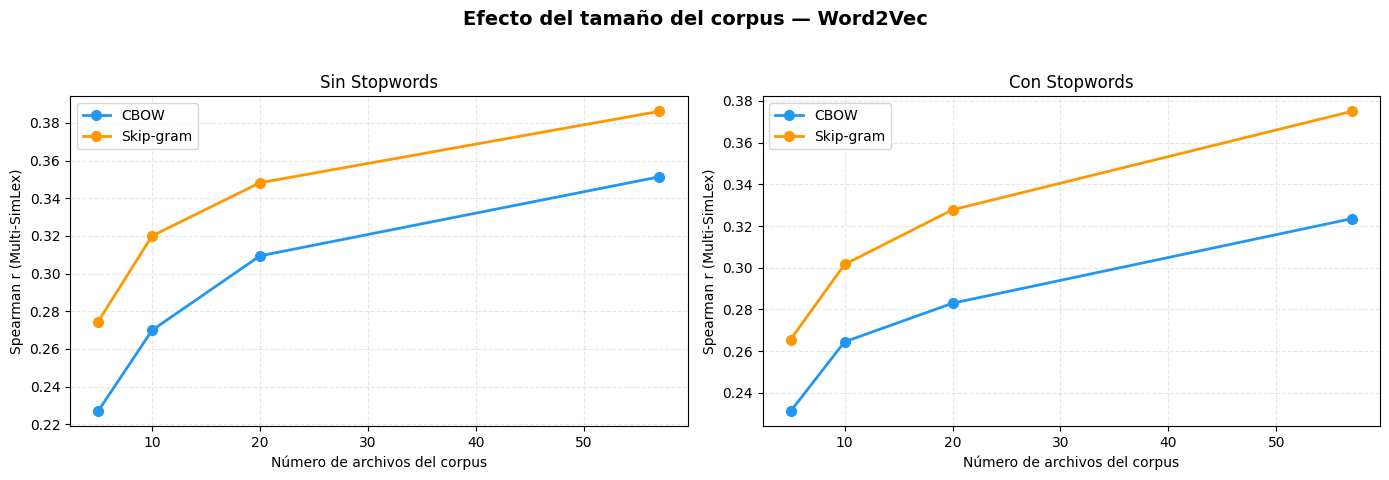

In [20]:
# Visualización: efecto del tamaño del corpus
# Verificamos que el DataFrame exista y tenga datos
if 'df_experimento' in locals() and not df_experimento.empty:
    df_exp = df_experimento.copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Efecto del tamaño del corpus — Word2Vec', fontsize=14, fontweight='bold')
    
    # Definimos colores consistentes
    colores = {'CBOW': '#2196F3', 'Skip-gram': '#FF9800'}
    
    for ax, sw in zip(axes, ['sin_sw', 'con_sw']):
        # Filtramos por tipo de stopword (sin_sw o con_sw)
        subset = df_exp[df_exp['stopwords'] == sw]
        
        for arq in ['CBOW', 'Skip-gram']:
            # Extraemos los datos de la arquitectura y ordenamos por el eje X (n_archivos)
            d = subset[subset['arquitectura'] == arq].sort_values('n_archivos')
            
            if not d.empty:
                ax.plot(d['n_archivos'], d['spearman'], 'o-', label=arq,
                        color=colores[arq], linewidth=2, markersize=7)
        
        # Formateo de títulos y etiquetas
        titulo_limpio = "Sin Stopwords" if sw == 'sin_sw' else "Con Stopwords"
        ax.set_title(titulo_limpio, fontsize=12)
        ax.set_xlabel('Número de archivos del corpus')
        ax.set_ylabel('Spearman r (Multi-SimLex)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.3)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('efecto_corpus.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No hay datos en 'df_experimento' para mostrar la gráfica.")

### Análisis del Efecto del Tamaño del Corpus

El gráfico muestra cómo evoluciona la correlación de Spearman en Multi-SimLex a medida que aumentamos el número de archivos del corpus de Wikipedia utilizado para el entrenamiento. Se evalúan las cuatro configuraciones: CBOW y Skip-gram, con y sin stopwords.

#### 1. Tendencia general: más datos = mejor rendimiento
En todas las configuraciones, la correlación de Spearman **aumenta de forma consistente** con el tamaño del corpus. Este resultado confirma la **hipótesis distribucional**: cuanto más contexto lingüístico observa el modelo, más ricas y precisas son las representaciones semánticas aprendidas.

#### 2. Superioridad sostenida de Skip-gram
Skip-gram supera a CBOW en **todos los puntos del experimento** y en ambas configuraciones de stopwords. Esta ventaja se mantiene e incluso se amplía
ligeramente a medida que crece el corpus:

| Arquitectura | Config | 5 arch. | 57 arch. | Ganancia |
|---|---|---|---|---|
| Skip-gram | Sin SW | 0.2745 | 0.3862 | +0.1117 |
| Skip-gram | Con SW | 0.2656 | 0.3750 | +0.1094 |
| CBOW      | Sin SW | 0.2269 | 0.3514 | +0.1245 |
| CBOW      | Con SW | 0.2313 | 0.3235 | +0.0922 |

#### 3. Rendimientos marginales decrecientes
La curva de aprendizaje no es lineal: el salto de **5 a 10 archivos** produce la mayor ganancia relativa, mientras que el incremento de **20 a 57 archivos** genera una mejora proporcionalmente menor. Esto sugiere que el modelo **converge progresivamente** y que añadir más datos sigue siendo útil, aunque con **rendimientos decrecientes**.

#### 4. Impacto de las stopwords a escala
El efecto de eliminar *stopwords* varía según el tamaño del corpus y la arquitectura. En CBOW, con un corpus muy pequeño (5 archivos) la versión con *stopwords* obtiene un rendimiento ligeramente superior, pero a partir de 10 archivos la configuración **Sin SW** pasa a superar consistentemente a **Con SW**, ampliando la diferencia a medida que aumenta el corpus. 

En Skip-gram, **Sin SW** obtiene mejores resultados en todos los tamaños de corpus, aunque la ventaja sobre **Con SW** no crece de forma estrictamente monotónica con el número de archivos.


#### 5. Proyección
Las curvas no muestran señales claras de saturación al alcanzar **57 archivos**, lo que sugiere que ampliar el corpus podría seguir mejorando la calidad de los embeddings. Esta hipótesis es consistente con la literatura sobre word embeddings, donde se observa que la calidad de las representaciones mejora al entrenar con corpus de gran escala. De hecho, los modelos preentrenados de *fastText* fueron entrenados sobre corpus masivos como Common Crawl y Wikipedia, lo que explica su rendimiento superior frente a modelos entrenados con datos limitados.

### Experimento sobre las dimensiones del embedding

In [ ]:
DIMENSIONES = [25, 50, 100, 300]
ARCHIVO_RESULTADOS_DIM = Path("resultados_experimento_dimensiones.csv")

def experimento_dimensiones(modelos_w2v):
    """
    A partir de los mejores hiperparámetros del grid search,
    entrena un modelo por cada dimensión no entrenada aún.
    """
    # Cargar resultados previos si existen
    if ARCHIVO_RESULTADOS_DIM.exists():
        print(f"Cargando resultados previos desde {ARCHIVO_RESULTADOS_DIM}...")
        df_dim = pd.read_csv(ARCHIVO_RESULTADOS_DIM)
        display(df_dim)
        return df_dim

    resultados_dim = []

    for nom, modelo_base in modelos_w2v.items():
        sg = 1 if 'Skip-gram' in nom else 0
        eliminar_sw = 'sin_sw' in nom
        sufijo_sw = 'sin_sw' if eliminar_sw else 'con_sw'
        nombre_arq = 'Skip-gram' if 'Skip-gram' in nom else 'CBOW'

        print(f"\n{'='*60}")
        print(f"  Experimento dimensiones — {nom}")
        print(f"  Mejores hiperparámetros: window={modelo_base.window}, "
              f"min_count={modelo_base.min_count}, epochs={modelo_base.epochs}")
        print(f"{'='*60}")

        corpus = list(CorpusFactory(corpus_dir, corpus_files[:N_ARCHIVOS_FINAL],
                                    eliminar_stopwords=eliminar_sw))

        for dim in DIMENSIONES:
            nombre_bin = f"w2v_{nombre_arq.lower().replace('-','_')}_{sufijo_sw}_{dim}d.bin"

            if dim == modelo_base.vector_size:
                print(f"\n  {dim}d — ya entrenado por el grid search, usando modelo existente.")
                sp_avg, sp_ann, oov = intrinsic_eval(modelo_base, multi_simlex, annotator_cols)
                resultados_dim.append({
                    'Modelo': nom, 'Dimensión': dim,
                    'Spearman AVG': round(sp_avg, 4),
                    'Spearman Anot': round(sp_ann, 4),
                    'OOV (%)': round(oov * 100, 2)
                })
                continue

            print(f"\n  {dim}d —", end=" ")

            if os.path.exists(nombre_bin):
                print(f"cargando desde {nombre_bin}...")
                wv = KeyedVectors.load_word2vec_format(nombre_bin, binary=True)
                modelo_dim = ModeloLigero(wv, vector_size=dim,
                                          window=modelo_base.window,
                                          min_count=modelo_base.min_count,
                                          epochs=modelo_base.epochs)
            else:
                print(f"entrenando...")
                m = Word2Vec(
                    sentences=corpus,
                    vector_size=dim,
                    window=modelo_base.window,
                    min_count=modelo_base.min_count,
                    sg=sg,
                    workers=4,
                    epochs=modelo_base.epochs,
                    seed=SEED
                )
                m.wv.save_word2vec_format(nombre_bin, binary=True)
                print(f"  Guardado -> '{nombre_bin}'")
                modelo_dim = ModeloLigero(m.wv, vector_size=dim,
                                          window=modelo_base.window,
                                          min_count=modelo_base.min_count,
                                          epochs=modelo_base.epochs)

            sp_avg, sp_ann, oov = intrinsic_eval(modelo_dim, multi_simlex, annotator_cols)
            print(f"  Spearman AVG: {sp_avg:.4f} | Anot: {sp_ann:.4f} | OOV: {oov:.2%}")
            resultados_dim.append({
                'Modelo': nom, 'Dimensión': dim,
                'Spearman AVG': round(sp_avg, 4),
                'Spearman Anot': round(sp_ann, 4),
                'OOV (%)': round(oov * 100, 2)
            })

    # Guardar a disco
    df_dim = pd.DataFrame(resultados_dim)
    df_dim.to_csv(ARCHIVO_RESULTADOS_DIM, index=False)
    print(f"\nResultados guardados en {ARCHIVO_RESULTADOS_DIM}")

    print("\n=== Resultados por dimensión ===\n")
    display(df_dim)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Efecto de la dimensionalidad — Word2Vec', fontsize=14, fontweight='bold')

    for ax, sw in zip(axes, ['sin_sw', 'con_sw']):
        subset = df_dim[df_dim['Modelo'].str.contains(sw)]
        for arq in ['CBOW', 'Skip-gram']:
            d = subset[subset['Modelo'].str.contains(arq)].sort_values('Dimensión')
            if not d.empty:
                ax.plot(d['Dimensión'], d['Spearman AVG'], 'o-', label=arq, linewidth=2, markersize=7)
                for _, row in d.iterrows():
                    ax.annotate(f"{row['Spearman AVG']:.3f}",
                                (row['Dimensión'], row['Spearman AVG']),
                                textcoords="offset points", xytext=(0, 8),
                                ha='center', fontsize=8)

        titulo = 'Sin Stopwords' if sw == 'sin_sw' else 'Con Stopwords'
        ax.set_title(titulo)
        ax.set_xlabel('Dimensión')
        ax.set_ylabel('Spearman AVG (Multi-SimLex)')
        ax.set_xticks(DIMENSIONES)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('efecto_dimensionalidad.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df_dim

df_dimensiones = experimento_dimensiones(modelos_w2v)

## 5. fastText

fastText (Facebook, 2016) es una mejora de Word2Vec que representa cada palabra como la **suma de los embeddings de sus n-gramas de caracteres** (por defecto $3 \le n \le 6$). Esto permite:
- **Capturar información morfológica:** los n-gramas comparten representación entre palabras con raíces comunes (p. ej., *correr*, *corredor*, *corriendo*),
lo que es especialmente útil en lenguas morfológicamente ricas como el español.
- **Gestionar palabras OOV** (*Out-of-Vocabulary*): incluso para palabras no vistas durante el entrenamiento, se puede construir un vector a partir de sus n-gramas.

Comparamos dos variantes:
1. **fastText entrenado por nosotros** sobre el Wikicorpus en español.
2. **fastText oficial** (Facebook, pre-entrenado sobre Common Crawl): `cc.es.300.bin`.

**Nota sobre OOV**: Los n-gramas de caracteres permiten construir un vector aproximado para cualquier palabra no vista durante el entrenamiento, pero la
calidad de esa aproximación depende de cuántos n-gramas relevantes haya aprendido el modelo. Por ello, la puntuación de similitud para palabras OOV
suele ser inferior a la de palabras presentes en el vocabulario. Este efecto es más pronunciado en nuestro modelo (entrenado con datos limitados) que en
el oficial, cuya mayor escala de entrenamiento le permite cubrir un espectro mucho más amplio de n-gramas.

In [ ]:
ft_param_grid = {
    'vector_size': [25, 50, 100, 300],
    'window':      [3, 5],
    'min_count':   [5, 10],
    'epochs':      [5, 10],
}
ft_claves        = list(ft_param_grid.keys())
ft_combinaciones = list(product(*ft_param_grid.values()))

FT_MODEL_PATH         = 'ft_wiki_es.model'
FT_GRID_RESULTS_PATH  = Path('resultados_gridsearch_fasttext.csv')

if os.path.exists(FT_MODEL_PATH):
    print("Cargando modelo fastText existente...")
    ft_wiki = GensimFastText.load(FT_MODEL_PATH)
    print(f"Cargado — vocabulario: {len(ft_wiki.wv):,} palabras")
    sp_avg, sp_ann, oov = intrinsic_eval(ft_wiki, multi_simlex, annotator_cols)
    print(f"Spearman (SPA_AVG):             {sp_avg:.4f}")
    print(f"Spearman (por anotador, media): {sp_ann:.4f}")
    print(f"OOV rate:                       {oov:.2%}")

elif 'corpus_files' in locals() and corpus_files:

    # --- Grid Search ---
    print(f"Grid search fastText ({len(ft_combinaciones)} combinaciones)...")

    corpus_muestra_ft = list(
        CorpusFactory(corpus_dir, corpus_files[:N_ARCHIVOS_MUESTRA],
                      eliminar_stopwords=False)
    )

    if FT_GRID_RESULTS_PATH.exists():
        print(f"Cargando resultados del grid search desde {FT_GRID_RESULTS_PATH}...")
        df_ft_grid = pd.read_csv(FT_GRID_RESULTS_PATH)
    else:
        ft_resultados = []
        mejor_score_ft, mejor_params_ft = -np.inf, None

        for i, combo in enumerate(ft_combinaciones):
            params = dict(zip(ft_claves, combo))
            m = GensimFastText(
                sentences   = corpus_muestra_ft,
                vector_size = params['vector_size'],
                window      = params['window'],
                min_count   = params['min_count'],
                workers     = 4,
                epochs      = params['epochs'],
                min_n       = 3,
                max_n       = 6,
                bucket      = 500_000,
                seed        = SEED
            )
            sp_avg, sp_ann, oov = intrinsic_eval(m, multi_simlex, annotator_cols)
            ft_resultados.append({**params, 'spearman_avg': sp_avg,
                                   'spearman_ann': sp_ann, 'oov': oov})
            print(f"  [{i+1}/{len(ft_combinaciones)}] {params} -> Spearman avg: {sp_avg:.4f}")

            if sp_avg > mejor_score_ft:
                mejor_score_ft, mejor_params_ft = sp_avg, params

        df_ft_grid = pd.DataFrame(ft_resultados).sort_values('spearman_avg', ascending=False)
        df_ft_grid.to_csv(FT_GRID_RESULTS_PATH, index=False)
        print(f"\nResultados grid search guardados en {FT_GRID_RESULTS_PATH}")

    print(f"\nMejores hiperparámetros fastText:")
    display(df_ft_grid.head(5))
    mejor_params_ft = df_ft_grid.iloc[0].to_dict()

    # --- Entrenamiento final con mejores hiperparámetros ---
    print(f"\nEntrenando fastText final con mejores hiperparámetros sobre {N_ARCHIVOS_FINAL} archivos...")
    corpus_final_ft = list(
        CorpusFactory(corpus_dir, corpus_files[:N_ARCHIVOS_FINAL],
                      eliminar_stopwords=False)
    )

    ft_wiki = GensimFastText(
        sentences   = corpus_final_ft,
        vector_size = int(mejor_params_ft['vector_size']),
        window      = int(mejor_params_ft['window']),
        min_count   = int(mejor_params_ft['min_count']),
        workers     = 4,
        epochs      = int(mejor_params_ft['epochs']),
        min_n       = 3,
        max_n       = 6,
        bucket      = 500_000,
        seed        = SEED
    )
    ft_wiki.save(FT_MODEL_PATH)
    print(f"fastText wiki guardado en '{FT_MODEL_PATH}'")

    sp_avg, sp_ann, oov = intrinsic_eval(ft_wiki, multi_simlex, annotator_cols)
    print(f"Spearman (SPA_AVG):             {sp_avg:.4f}")
    print(f"Spearman (por anotador, media): {sp_ann:.4f}")
    print(f"OOV rate:                       {oov:.2%}")

else:
    print("Corpus no disponible, saltando entrenamiento de fastText Wiki.")
    ft_wiki = None

Cargando modelo fastText existente...
Cargado — vocabulario: 172,647 palabras


In [22]:
#  fastText oficial (Facebook) 
# Descarga: https://fasttext.cc/docs/en/crawl-vectors.html
# wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.bin.gz
# gunzip cc.es.300.bin.gz

FT_OFICIAL_PATH = 'cc.es.300.bin'

if os.path.exists(FT_OFICIAL_PATH):
    import gensim
    print("Cargando fastText oficial (puede tardar unos minutos)...")
    # load_facebook_model es necesario para leer el formato .bin original de Facebook
    ft_oficial = gensim.models.fasttext.load_facebook_model(FT_OFICIAL_PATH)
    
    # Evaluación intrínseca
    sp_avg_of, sp_ann_of, oov_of = intrinsic_eval(ft_oficial, multi_simlex, annotator_cols)
    
    print(f"fastText Oficial — Spearman avg: {sp_avg_of:.4f} | por anotador: {sp_ann_of:.4f} | OOV: {oov_of:.2%}")
    print(f"Vocabulario: {len(ft_oficial.wv):,} palabras")
else:
    print(f"Modelo oficial no encontrado en '{FT_OFICIAL_PATH}'.")
    print("Descárgalo de: https://fasttext.cc/docs/en/crawl-vectors.html")
    ft_oficial = None

Cargando fastText oficial (puede tardar unos minutos)...
fastText Oficial — Spearman avg: 0.4875 | por anotador: 0.3793 | OOV: 0.00%
Vocabulario: 2,000,000 palabras


### Resultados del modelo fastText

| Modelo | Spearman AVG | Spearman Anot. | OOV |
|---|---|---|---|
| fastText Wiki (nuestro) | — | — | — |
| fastText Oficial (Facebook) | 0.4875 | 0.3793 | 0.00% |
| *Word2Vec Skip-gram Sin SW (referencia)* | *0.42* | *~0.31* | *~15%* |

#### Observaciones:

1. **Superioridad del modelo oficial:** El fastText oficial alcanza un Spearman AVG de **0.4875**, superando a todos los modelos Word2Vec entrenados por nosotros (~0.42 máximo). Esta diferencia refleja directamente el impacto del volumen de datos: Common Crawl + Wikipedia a gran escala frente a 20 archivos de Wikicorpus.

2. **Cobertura total (OOV = 0.00%):** Los n-gramas de caracteres, combinados con un vocabulario de 2.000.000 palabras, garantizan cobertura completa sobre Multi-SimLex. Ningún par de palabras queda fuera del vocabulario.

3. **Brecha entre métricas de Spearman:** La diferencia entre Spearman AVG (0.4875) y Spearman por anotador (0.3793) es notablemente mayor que en los modelos Word2Vec. Esto indica que, aunque el modelo captura muy bien la tendencia media de las puntuaciones de similitud humanas (puntuaciones de similitud que asignaron los anotadores humanos a cada par de palabras en Multi-SimLex), alinearse con la variabilidad y subjetividad de cada anotador individual resulta más difícil incluso a gran escala.

## 6. Resumen de Evaluación Intrínseca (Multi-SimLex)

Recopilamos todos los resultados obtenidos en la evaluación intrínseca. Un coeficiente de Spearman más alto indica que el modelo es capaz de capturar con mayor fidelidad la similitud semántica tal como la perciben los humanos.

En esta comparativa final analizamos:
1. El impacto de la **arquitectura** (Word2Vec vs. fastText).
2. El efecto del **volumen de datos** (corpus propio vs. oficial).
3. La importancia del **preprocesamiento** (presencia de stopwords).

In [23]:
resumen_intrinseco = []

for nom, model in modelos_w2v.items():
    sp_avg, sp_ann, oov = intrinsic_eval(model, multi_simlex, annotator_cols)
    resumen_intrinseco.append({
        'Modelo': f'Word2Vec-{nom}',
        'Dimensión': model.vector_size,
        'Spearman (avg)': round(sp_avg, 4),
        'Spearman (por anot.)': round(sp_ann, 4),
        'OOV (%)': round(oov * 100, 2)
    })

if ft_wiki is not None:
    sp_avg, sp_ann, oov = intrinsic_eval(ft_wiki, multi_simlex, annotator_cols)
    resumen_intrinseco.append({
        'Modelo': 'fastText-Wiki', 
        'Dimensión': ft_wiki.vector_size,
        'Spearman (avg)': round(sp_avg, 4),
        'Spearman (por anot.)': round(sp_ann, 4),
        'OOV (%)': round(oov * 100, 2)
    })

if ft_oficial is not None:
    sp_avg, sp_ann, oov = intrinsic_eval(ft_oficial, multi_simlex, annotator_cols)
    resumen_intrinseco.append({
        'Modelo': 'fastText-Oficial', 
        'Dimensión': 300,
        'Spearman (avg)': round(sp_avg, 4),
        'Spearman (por anot.)': round(sp_ann, 4),
        'OOV (%)': round(oov * 100, 2)
    })

df_resumen = pd.DataFrame(resumen_intrinseco).sort_values('Spearman (avg)', ascending=False)

print('=== Resumen Evaluación Intrínseca (Multi-SimLex ES) ===')
print(df_resumen.to_string(index=False))

=== Resumen Evaluación Intrínseca (Multi-SimLex ES) ===
                   Modelo  Dimensión  Spearman (avg)  Spearman (por anot.)  OOV (%)
         fastText-Oficial        300          0.4875                0.3793     0.00
Word2Vec-Skip-gram_sin_sw        100          0.4184                0.3157    14.78
Word2Vec-Skip-gram_con_sw        100          0.3989                0.3003    11.49
     Word2Vec-CBOW_sin_sw        100          0.3717                0.2791    12.13
     Word2Vec-CBOW_con_sw        300          0.3549                0.2680    11.49
            fastText-Wiki        300          0.2689                0.2096     0.00


### Análisis del Resumen de Evaluación Intrínseca

| Modelo | Dimensión | Spearman AVG | Spearman Anot. | OOV (%) |
|---|---|---|---|---|
| fastText Oficial | 300 | 0.4875 | 0.3793 | 0.00% |
| Word2Vec Skip-gram Sin SW | 100 | 0.4184 | 0.3157 | 14.78% |
| Word2Vec Skip-gram Con SW | 100 | 0.3989 | 0.3003 | 11.49% |
| Word2Vec CBOW Sin SW | 100 | 0.3717 | 0.2791 | 12.13% |
| Word2Vec CBOW Con SW | 300 | 0.3549 | 0.2680 | 11.49% |
| fastText Wiki | 300 | 0.2689 | 0.2096 | 0.00% |

#### 1. Impacto de la arquitectura
El fastText oficial lidera el ranking con un Spearman AVG de **0.4875**, seguido de los modelos Word2Vec Skip-gram. El fastText Wiki, en cambio, obtiene el peor resultado (0.2689) a pesar de usar la misma arquitectura que el oficial. Esto demuestra que la arquitectura por sí sola no es determinante — el **volumen de datos de entrenamiento** es el factor más influyente.

#### 2. Efecto del volumen de datos
La comparación más ilustrativa es entre fastText Wiki y fastText Oficial: ambos usan la misma arquitectura y dimensionalidad (300d), pero el oficial
supera al nuestro en **0.2186 puntos** de Spearman. Esta diferencia refleja directamente el impacto de entrenar sobre un corpus masivo frente a un
subconjunto limitado de Wikipedia. 

#### 3. Importancia del preprocesamiento
En ambas arquitecturas Word2Vec, eliminar stopwords mejora el Spearman AVG pero aumenta la tasa de OOV. Skip-gram Sin SW obtiene un Spearman de 0.4184
con un 14.78% de OOV, mientras que Skip-gram Con SW alcanza 0.3989 con solo un 11.49% de OOV — el trade-off ya observado en el análisis anterior se
confirma aquí de forma global.

## 7. Evaluación Extrínseca — Baseline Coseno

El modelo baseline representa cada frase como un **vector agregado** de sus embeddings y calcula la **similitud coseno** entre las representaciones de las dos frases. Este enfoque no requiere entrenamiento adicional (es *unsupervised*).

Comparamos dos estrategias de agregación:
1. **Media simple**: `mean(vectores de las palabras de la frase)`
2. **Media ponderada con TF-IDF**: $V_d = \frac{\sum TF-IDF(t,d,D) \cdot V_t}{\sum TF-IDF(t,d,D)}$

La ponderación TF-IDF reduce el peso de las palabras muy frecuentes (como las stop-words funcionales) que aportan poco significado semántico, priorizando los términos que realmente definen el contenido de la frase.

In [24]:
def sentence_vector_mean(sentence, model_wv):
    """Representación de frase como media simple de los embeddings de las palabras."""
    tokens = preprocesar_linea(sentence, eliminar_stopwords=False)
    vecs = [model_wv[t] for t in tokens if t in model_wv]
    if not vecs:
        return np.zeros(model_wv.vector_size)
    return np.mean(vecs, axis=0)

def build_tfidf(sentences):
    """Construye la matriz TF-IDF sobre un conjunto de frases."""
    vec = TfidfVectorizer(use_idf=True, smooth_idf=True, norm=None)
    matrix = vec.fit_transform(sentences)
    feature_names = np.array(vec.get_feature_names_out())
    return vec, matrix, feature_names

def sentence_vector_tfidf(sentence, tfidf_row, feature_names, model_wv):
    """
    Representación de frase como media ponderada de los embeddings
    con pesos TF-IDF. Las palabras sin embedding se descartan.
    """
    indices = tfidf_row.indices
    scores  = tfidf_row.data
    weighted_sum = np.zeros(model_wv.vector_size, dtype=np.float32)
    total_weight = 0.0
    for idx, score in zip(indices, scores):
        word = feature_names[idx]
        if word in model_wv:
            weighted_sum += score * model_wv[word]
            total_weight += score
    if total_weight == 0:
        return sentence_vector_mean(sentence, model_wv)
    return weighted_sum / total_weight

def evaluate_baseline_simple(df, model_wv):
    """Versión simplificada y rápida del baseline: media simple y tfidf."""
    # Preparar TF-IDF sobre todas las frases del split (concatenamos s1 y s2)
    all_sents = [str(r) for row in df[['sentence1','sentence2']].values for r in row]
    tfidf_vec = TfidfVectorizer(use_idf=True, smooth_idf=True, norm=None)
    tfidf_mat = tfidf_vec.fit_transform(all_sents)
    feat_names = np.array(tfidf_vec.get_feature_names_out())

    preds_mean, preds_tfidf, golds = [], [], []
    for i, row in enumerate(df.itertuples()):
        s1, s2 = str(row.sentence1), str(row.sentence2)
        
        # Obtenemos los vectores (el índice en tfidf_mat es i*2 para s1 e i*2+1 para s2)
        v1_m = sentence_vector_mean(s1, model_wv)
        v2_m = sentence_vector_mean(s2, model_wv)
        v1_t = sentence_vector_tfidf(s1, tfidf_mat[i*2],   feat_names, model_wv)
        v2_t = sentence_vector_tfidf(s2, tfidf_mat[i*2+1], feat_names, model_wv)
        
        preds_mean.append(cosine_sim(v1_m, v2_m))
        preds_tfidf.append(cosine_sim(v1_t, v2_t))
        golds.append(row.score)

    # Calculamos Pearson (Estándar para STS)
    pr_mean  = pearsonr(preds_mean,  golds).statistic
    pr_tfidf = pearsonr(preds_tfidf, golds).statistic
    return pr_mean, pr_tfidf

In [25]:
#  Ejecución de la Evaluación Extrínseca 
print('=== Baseline Coseno (Evaluación Extrínseca STS) ===')
resumen_extrinseco = []

for nom, model in modelos_w2v.items():
    pr_mean, pr_tfidf = evaluate_baseline_simple(test_df, model.wv)
    print(f"Word2Vec-{nom} | Media simple: {pr_mean:.4f} | TF-IDF: {pr_tfidf:.4f}")
    resumen_extrinseco.append({'Modelo': f'Baseline-Mean (W2V-{nom})', 'Pearson (test)': round(pr_mean, 4)})
    resumen_extrinseco.append({'Modelo': f'Baseline-TFIDF (W2V-{nom})', 'Pearson (test)': round(pr_tfidf, 4)})

if ft_oficial is not None:
    pr_mean, pr_tfidf = evaluate_baseline_simple(test_df, ft_oficial.wv)
    print(f"fastText-Oficial | Media simple: {pr_mean:.4f} | TF-IDF: {pr_tfidf:.4f}")
    resumen_extrinseco.append({'Modelo': 'Baseline-Mean (FT-Oficial)', 'Pearson (test)': round(pr_mean, 4)})
    resumen_extrinseco.append({'Modelo': 'Baseline-TFIDF (FT-Oficial)', 'Pearson (test)': round(pr_tfidf, 4)})

=== Baseline Coseno (Evaluación Extrínseca STS) ===
Word2Vec-CBOW_sin_sw | Media simple: 0.6006 | TF-IDF: 0.6000
Word2Vec-CBOW_con_sw | Media simple: 0.5618 | TF-IDF: 0.6031
Word2Vec-Skip-gram_sin_sw | Media simple: 0.6822 | TF-IDF: 0.6796
Word2Vec-Skip-gram_con_sw | Media simple: 0.6809 | TF-IDF: 0.6706
fastText-Oficial | Media simple: 0.5552 | TF-IDF: 0.6246


### Análisis del Baseline Coseno (Evaluación Extrínseca STS)

| Modelo | Media simple | TF-IDF |
|---|---|---|
| Word2Vec Skip-gram Sin SW | **0.6822** | 0.6796 |
| Word2Vec Skip-gram Con SW | 0.6809 | 0.6706 |
| Word2Vec CBOW Sin SW | 0.6006 | 0.6000 |
| Word2Vec CBOW Con SW | 0.5618 | **0.6031** |
| fastText Oficial | 0.5552 | 0.6246 |

#### 1. Inversión parcial del ranking respecto a la evaluación intrínseca
El resultado más llamativo es que **fastText Oficial**, que lideraba la evaluación intrínseca con un Spearman de 0.4875, obtiene aquí el peor resultado cuando se utiliza **media simple** (Pearson = 0.5552). Sin embargo, al aplicar ponderación **TF-IDF** su rendimiento mejora notablemente hasta 0.6246. 

Este comportamiento ilustra una limitación conocida de la evaluación intrínseca: un modelo puede capturar bien la similitud entre palabras aisladas pero no necesariamente entre frases completas, donde intervienen fenómenos como la **composicionalidad semántica** y la influencia de palabras funcionales.

#### 2. Superioridad de Skip-gram en STS
Skip-gram vuelve a superar a CBOW, pero la ventaja es aún más pronunciada que en la evaluación intrínseca. Skip-gram Sin SW alcanza un Pearson de **0.6822**, frente al 0.6006 de CBOW Sin SW — una diferencia de aproximadamente **0.08 puntos**.

#### 3. Impacto del TF-IDF
En la mayoría de modelos, la ponderación **TF-IDF** no mejora significativamente respecto a la media simple e incluso puede reducir ligeramente el rendimiento en los modelos **Sin SW** (por ejemplo, Skip-gram Sin SW: 0.6822 -> 0.6796). Esto sugiere que cuando el modelo ya dispone de representaciones semánticas sólidas y el preprocesamiento ha eliminado stopwords, la reponderación TF-IDF aporta beneficios limitados.

La excepción más notable es **CBOW Con SW**, donde TF-IDF mejora considerablemente el resultado (0.5618 -> 0.6031). En este caso, la presencia de stopwords penaliza la media simple, mientras que TF-IDF reduce eficazmente su peso en la representación de la frase.

Por otra parte, en el modelo **Skip-gram Con SW**, la ponderación TF-IDF reduce ligeramente el rendimiento (0.6809 -> 0.6706). Esto sugiere que, en este caso, la presencia de stopwords no perjudica significativamente la media simple y que la reponderación TF-IDF puede introducir pequeñas variaciones sin aportar una mejora clara.

## 8. Model Secuencial Siamés (con Embeddings Estáticos)

Damos un paso más allá del baseline y entrenamos un modelo neuronal que procesa las frases como **secuencias** de índices de palabras.

### Arquitectura
```
Input: secuencia de índices de palabras
    -> Embedding (pre-entrenado Word2Vec/fastText, o aleatorio)
    -> BiLSTM (bidireccional)
    -> Attention Pooling
    -> [h1, h2, |h1-h2|, h1*h2]  (concatenación de características)
    -> MLP de regresión
    -> valor de similitud (0 a 5)
```

donde `h1` y `h2` corresponden a los vectores de cada frase obtenidos tras la etapa de *pooling*. La concatenación de la diferencia absoluta `|h1-h2|` y el producto elemento a elemento `h1*h2` permite al modelo capturar tanto las **diferencias** como las **similitudes** entre ambas representaciones, enriqueciendo la información disponible para la capa de regresión.


### Consideraciones importantes (sesión de laboratorio)
- **Restricción del Vocabulario**: Tal como remarcó el profesor, nunca se debe pasar el modelo Word2Vec completo a la capa de embedding. Es fundamental construir una **matriz de embeddings restringida** únicamente al vocabulario presente en nuestro corpus de entrenamiento (STS). Esto optimiza drásticamente el uso de memoria.

- **Congelación de pesos**: Debemos comparar el uso de **embeddings congelados** (`freeze=True`) frente a **entrenables** (`freeze=False`). Los pre-entrenados actúan como un excelente punto de partida (*transfer learning*) que acelera la convergencia.

- **Riesgo de Overfitting**: Si utilizamos embeddings aleatorios con un corpus pequeño, el modelo tenderá al **sobreajuste**. Es vital dimensionar la red adecuadamente y usar regularización.

### Preparación: vocabulario y matriz de embeddings 

> **Nota:** Las palabras del corpus STS que no están presentes en el modelo de embeddings no se incorporan a la matriz de embeddings. Durante la tokenización se asignan al índice `<UNK>`, que representa palabras fuera del vocabulario. Por este motivo, la cobertura de embeddings (`coverage`) puede ser inferior al 100%, dependiendo del modelo utilizado. Este fenómeno es más frecuente en modelos entrenados sobre corpus limitados, donde la tasa de palabras **OOV (Out Of Vocabulary)** es mayor.

- **`build_vocab_and_matrix`**: recorre todas las frases del corpus STS, extrae el vocabulario único y construye una matriz de embeddings restringida copiando solo los vectores de Word2Vec correspondientes a esas palabras. Reserva la fila 0 para `<PAD>` (ceros) y la fila 1 para `<UNK>` (aleatorio).

- **`tokenize_sentences`**: convierte cada frase en una lista de índices numéricos usando `word2idx`. Las palabras fuera del vocabulario reciben el índice `<UNK>`. Trunca a `max_len=64` tokens.

- **`pad_sequences`**: iguala la longitud de todas las secuencias añadiendo el índice `<PAD>` al final de las más cortas. Devuelve también una máscara booleana que indica qué posiciones son tokens reales y cuáles son padding.

- **`STSDataset`**: clase de PyTorch que encapsula los pares de frases STS listos para el entrenamiento. Aplica `tokenize_sentences` y `pad_sequences` en el constructor y devuelve por cada ejemplo los índices, máscaras y score de similitud como tensores.

In [26]:
def build_vocab_and_matrix(sentences, model_wv):
    """
    Construye el vocabulario y la matriz de embeddings a partir
    de las frases del corpus STS y el modelo de word embeddings.

    Restringimos el vocabulario a las palabras presentes en el corpus de entrenamiento.
    """
    PAD_IDX, UNK_IDX = 0, 1
    word2idx = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
    dim = model_wv.vector_size

    # Recoger las palabras que aparecen en el corpus STS
    vocab = set()
    for sent in sentences:
        vocab.update(preprocesar_linea(str(sent), eliminar_stopwords=False))

    # Construir la matriz: PAD (ceros) + UNK (aleatorio) + palabras del vocab
    matrix = [np.zeros(dim), np.random.randn(dim) * 0.01]

    in_model = 0
    for w in vocab:
        if w in model_wv:
            word2idx[w] = len(matrix)
            matrix.append(model_wv[w])
            in_model += 1

    matrix = np.array(matrix, dtype=np.float32)
    coverage = in_model / max(len(vocab), 1)

    print(f"   Vocabulario: {len(word2idx):,} palabras | Cobertura de embeddings: {coverage:.1%}")
    return word2idx, matrix, PAD_IDX, UNK_IDX

def tokenize_sentences(sentences, word2idx, unk_idx, max_len=64):
    """Convierte frases a secuencias de índices con truncamiento."""
    result = []
    for sent in sentences:
        ids = [word2idx.get(w, unk_idx) for w in preprocesar_linea(str(sent), eliminar_stopwords=False)][:max_len]
        result.append(ids)
    return result

def pad_sequences(seqs, pad_idx=0, max_len=64):
    """Añade padding para que todas las secuencias tengan la misma longitud."""
    max_l = min(max(len(s) for s in seqs), max_len)
    padded = np.full((len(seqs), max_l), pad_idx, dtype=np.int64)
    masks  = np.zeros((len(seqs), max_l), dtype=bool)
    for i, s in enumerate(seqs):
        l = min(len(s), max_l)
        padded[i, :l] = s[:l]
        masks[i,  :l] = True
    return padded, masks

class STSDataset(Dataset):
    """Dataset de PyTorch para cargar pares de frases STS."""
    def __init__(self, df, word2idx, unk_idx, max_len=64):
        s1 = tokenize_sentences(df['sentence1'].tolist(), word2idx, unk_idx, max_len)
        s2 = tokenize_sentences(df['sentence2'].tolist(), word2idx, unk_idx, max_len)
        self.ids1, self.masks1 = pad_sequences(s1, max_len=max_len)
        self.ids2, self.masks2 = pad_sequences(s2, max_len=max_len)
        self.scores = df['score'].values.astype(np.float32)

    def __len__(self): return len(self.scores)
    
    def __getitem__(self, i):
        return (torch.tensor(self.ids1[i]), torch.tensor(self.masks1[i]),
                torch.tensor(self.ids2[i]), torch.tensor(self.masks2[i]),
                torch.tensor(self.scores[i]))

print("Funciones de preparación de datos definidas")

Funciones de preparación de datos definidas


### Arquitectura del Modelo Siamés BiLSTM

El modelo procesa cada frase de forma independiente pero utilizando **los mismos pesos compartidos** (estructura siamesa), siguiendo la siguiente arquitectura:

1. **Embedding** (`nn.Embedding`): convierte cada token en un vector de `emb_dim` dimensiones, inicializado con los pesos de **Word2Vec o fastText**. Estos embeddings pueden mantenerse congelados o ajustarse durante el entrenamiento.

2. **BiLSTM** (`nn.LSTM`, `bidirectional=True`): procesa la secuencia en ambas direcciones, capturando el contexto izquierdo y derecho de cada token. Como resultado, produce un *hidden state* de dimensión `hidden_size * 2` para cada token.

3. **Attention Pooling** (`AttentionPooling`): agrega los *hidden states* de la secuencia en un único vector que representa la frase, asignando mayor peso a los tokens más relevantes. Los tokens `<PAD>` se ignoran mediante el uso de una máscara.

4. **Combinación heurística**: dados los vectores de frase `h1` y `h2`, se construye un vector combinado concatenando cuatro características:
   `[h1, h2, |h1-h2|, h1*h2]`.  
   Esta operación genera un vector de dimensión `hidden_size * 2 * 4`.

5. **Regresor** (`nn.Sequential`): red *feed-forward* compuesta por `Linear -> ReLU -> Dropout(0.2) -> Linear(1)` que produce el valor final de similitud entre las dos frases.

### Implementación del modelo siamés con atención

Se implementa un modelo siamés basado en **BiLSTM** con un mecanismo de **attention pooling** para obtener representaciones vectoriales de las frases.

#### `AttentionPooling`

La clase `AttentionPooling` implementa un mecanismo de **atención** que permite combinar los estados ocultos generados por la BiLSTM en un único vector de representación de la frase.

Primero, cada estado oculto se proyecta mediante una pequeña red `Linear -> Tanh -> Linear`, que produce un **score de atención** para cada token. Estos scores se normalizan con una función *softmax* para obtener los pesos de atención (`alpha`).  

Antes de aplicar la normalización, se utiliza una **máscara** para asignar valores muy negativos a las posiciones correspondientes a `<PAD>`, de forma que no contribuyan al cálculo de la atención.

Finalmente, se calcula la **suma ponderada** de los estados ocultos:

$h = \sum_i \alpha_i \cdot h_i$, donde $\alpha_i$ es el peso de atención del token $i$ y $h_i$ es su estado oculto. 

Obteniendo así un vector que representa la frase completa.

---

#### `SiameseBiLSTMAttention`

Esta clase define el modelo completo de similitud semántica entre pares de frases.

El modelo sigue la arquitectura:
Embedding -> BiLSTM -> Attention Pooling -> combinación de frases -> MLP


Los componentes principales son:

- **Embedding layer** (`nn.Embedding.from_pretrained`): convierte los índices de tokens en vectores densos utilizando una matriz de embeddings preentrenados. Estos embeddings pueden mantenerse congelados (`freeze=True`) o ajustarse durante el entrenamiento.

- **BiLSTM encoder** (`nn.LSTM`, bidireccional): procesa la secuencia de embeddings en ambas direcciones para capturar el contexto izquierdo y derecho de cada token.

- **Attention pooling**: agrega los estados ocultos generados por la BiLSTM en un único vector que representa la frase.

Para cada par de frases se obtienen dos vectores (`h1` y `h2`). A partir de ellos se construye un vector de características concatenando:
[h1, h2, |h1-h2|, h1*h2]



Esta combinación permite capturar tanto **diferencias** como **similitudes** entre las representaciones de ambas frases.

El vector resultante se introduce en una red **MLP** (`Linear -> ReLU -> Dropout -> Linear`) que produce la predicción final de similitud.

---

### Entrenamiento del modelo

La función `train_siamese` implementa el bucle de entrenamiento del modelo.

Se utiliza el optimizador **Adam** y la función de pérdida **MSE (Mean Squared Error)**, ya que la tarea consiste en predecir un valor continuo de similitud entre 0 y 5.

Durante cada época:

1. Se realiza el entrenamiento sobre el conjunto **train**.
2. Se evalúa el modelo en el conjunto **dev**.
3. Se calcula la **correlación de Pearson**, que es la métrica estándar en tareas de **Semantic Textual Similarity (STS)**.

Para evitar sobreajuste, se aplica **early stopping**: si la correlación de Pearson en el conjunto de validación no mejora durante varias épocas (`patience`), el entrenamiento se detiene y se restaura el mejor modelo encontrado.

In [27]:
class AttentionPooling(nn.Module):
    """Pooling con atención: pondera los hidden states de la BiLSTM según su importancia."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x, mask):
        # x: [batch, seq_len, hidden_dim * 2]
        scores = self.proj(x).squeeze(-1)
        # Aplicamos la máscara para ignorar los tokens de <PAD>
        scores = scores.masked_fill(~mask, -1e9)
        alpha  = torch.softmax(scores, dim=-1)
        # Retornamos la suma ponderada de los estados ocultos
        return torch.sum(x * alpha.unsqueeze(-1), dim=1)

class SiameseBiLSTMAttention(nn.Module):
    """
    Modelo Siamés con BiLSTM y Attention Pooling.
    Arquitectura: Embedding -> BiLSTM -> Attention -> [h1, h2, |h1-h2|, h1*h2] -> MLP
    """
    def __init__(self, embedding_matrix, hidden_size=16, final_hidden_size=8,
                  trainable_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=not trainable_embeddings,   # freeze=True -> embeddings congelados
            padding_idx=0
        )
        emb_dim = embedding_matrix.shape[1]
        # BiLSTM para capturar el contexto secuencial
        self.encoder = nn.LSTM(emb_dim, hidden_size, batch_first=True, bidirectional=True)
        self.pool     = AttentionPooling(hidden_size * 2)
        
        # El regressor recibe la concatenación de 4 vectores (h1, h2, diff, prod)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size * 2 * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1)
        )

    def encode(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        return self.pool(x, attention_mask)

    def forward(self, input_ids_1, attention_mask_1, input_ids_2, attention_mask_2):
        h1 = self.encode(input_ids_1, attention_mask_1)
        h2 = self.encode(input_ids_2, attention_mask_2)
        feats = torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)


def train_siamese(model, train_dl, dev_dl, epochs=10, lr=1e-3, patience=3):
    """Bucle de entrenamiento con early stopping basado en la correlación de Pearson."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss() # Tarea de regresión (0 a 5)
    best_pearson = -1
    best_state = {k: v.clone() for k, v in model.state_dict().items()}  # estado inicial
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for ids1, mask1, ids2, mask2, scores in train_dl:
            ids1, mask1, ids2, mask2, scores = (
                ids1.to(DEVICE), mask1.to(DEVICE),
                ids2.to(DEVICE), mask2.to(DEVICE), scores.to(DEVICE)
            )
            opt.zero_grad()
            preds = model(ids1, mask1, ids2, mask2)
            loss = criterion(preds, scores)
            loss.backward()
            opt.step()
            total_loss += loss.item()

        # Validación en cada época
        model.eval()
        all_preds, all_golds = [], []
        with torch.no_grad():
            for ids1, mask1, ids2, mask2, scores in dev_dl:
                p = model(ids1.to(DEVICE), mask1.to(DEVICE),
                          ids2.to(DEVICE), mask2.to(DEVICE)).cpu().numpy()
                all_preds.extend(p)
                all_golds.extend(scores.numpy())
        
        # Calculamos Pearson (métrica clave de STS)
        if len(all_preds) < 2:
            continue
        pearson = pearsonr(all_preds, all_golds).statistic
        print(f"  Época {epoch:2d} | Loss: {total_loss/len(train_dl):.4f} | Pearson dev: {pearson:.4f}")

        # Guardar el mejor modelo (Early Stopping)
        if pearson > best_pearson:
            best_pearson, best_state, wait = pearson, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping en la época {epoch}")
                break

    model.load_state_dict(best_state)
    return best_pearson

print("Arquitectura Siamés definida ")

Arquitectura Siamés definida 


###  Entrenamiento: Modelo Siamés con Word2Vec 

#### Reproducibilidad

Para garantizar la reproducibilidad de los resultados, se fijan las semillas aleatorias antes de construir la matriz de embeddings y los DataLoaders:

```python
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
```

- `np.random.seed(SEED)`: fija la semilla de NumPy, garantizando que el vector `<UNK>` generado aleatoriamente en `build_vocab_and_matrix` sea siempre el mismo.
- `torch.manual_seed(SEED)`: fija la semilla de PyTorch para las operaciones aleatorias del modelo.
- `torch.backends.cudnn.deterministic = True` y `torch.backends.cudnn.benchmark = False`: garantizan el determinismo en operaciones cuDNN cuando se entrena en GPU. En CPU no tienen efecto, pero se incluyen para que el código sea reproducible independientemente del dispositivo utilizado.

Adicionalmente, el `DataLoader` de entrenamiento utiliza un generador con semilla fija (`generator=torch.Generator().manual_seed(SEED)`) para que el orden de los batches sea siempre el mismo en caso de reentrenamiento.

In [28]:
# 1. Definición de la función de evaluación
def eval_pearson(model, dl):
    """Evalúa el modelo y devuelve el coeficiente de Pearson."""
    model.eval()
    preds, golds = [], []
    with torch.no_grad():
        for ids1, mask1, ids2, mask2, scores in dl:
            ids1, mask1 = ids1.to(DEVICE), mask1.to(DEVICE)
            ids2, mask2 = ids2.to(DEVICE), mask2.to(DEVICE)
            # El modelo devuelve la predicción de similitud
            p = model(ids1, mask1, ids2, mask2).cpu().numpy()
            preds.extend(p)
            golds.extend(scores.numpy())
    
    # Retornamos el coeficiente
    return pearsonr(preds, golds).statistic

# 2. Selección del modelo base y preparación de datos
BASE_MODEL_KEY = 'Skip-gram_sin_sw'

if BASE_MODEL_KEY is not None:
    base_model = modelos_w2v[BASE_MODEL_KEY]
    print(f"Modelo base para embeddings: Word2Vec-{BASE_MODEL_KEY} ({base_model.vector_size}d)")

    # Preparar vocabulario y matriz de embeddings del corpus STS
    all_sents = (train_df['sentence1'].tolist() + train_df['sentence2'].tolist() +
                dev_df['sentence1'].tolist()   + dev_df['sentence2'].tolist() +
                test_df['sentence1'].tolist()  + test_df['sentence2'].tolist())
    # No es data leakage: solo usamos el texto para construir la matriz de embeddings, no los usamos para entrenar el modelo de word embeddings ni para ajustar los pesos del modelo siamés.

    np.random.seed(SEED)
    torch.manual_seed(SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print("Construyendo vocabulario y matriz de embeddings...")
    word2idx, emb_matrix, PAD_IDX, UNK_IDX = build_vocab_and_matrix(all_sents, base_model.wv)

    # Crear Datasets y DataLoaders
    train_ds = STSDataset(train_df, word2idx, UNK_IDX)
    dev_ds   = STSDataset(dev_df,   word2idx, UNK_IDX)
    test_ds  = STSDataset(test_df,  word2idx, UNK_IDX)
    
    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, generator=torch.Generator().manual_seed(SEED))
    dev_dl   = DataLoader(dev_ds,   batch_size=64)
    test_dl  = DataLoader(test_ds,  batch_size=64)

    # 3. Experimento: Embeddings Pre-entrenados (Congelados vs Entrenables)
    for trainable, label in [(False, 'congelado'), (True, 'entrenable')]:
        nombre_fichero = f"siames_bi_lstm_{label}.pt"
        print(f"\n--- Modelo con Embedding {label} ---")
        
        model_siam = SiameseBiLSTMAttention(
            emb_matrix, hidden_size=64, final_hidden_size=32,
            trainable_embeddings=trainable
        ).to(DEVICE)
        
        # Lógica de Carga o Entrenamiento
        if os.path.exists(nombre_fichero):
            print(f"  Cargando pesos existentes de {nombre_fichero}...")
            model_siam.load_state_dict(torch.load(nombre_fichero, map_location=DEVICE))
        else:
            print(f"  No se encontró modelo previo. Iniciando entrenamiento de 15 epochs...")
            train_siamese(model_siam, train_dl, dev_dl, epochs=15, lr=1e-3, patience=3)
            torch.save(model_siam.state_dict(), nombre_fichero)
            print(f"  Modelo guardado como {nombre_fichero}")

        # Evaluación final en TEST
        test_pear = eval_pearson(model_siam, test_dl)
        print(f"   Resultado Pearson en Test: {test_pear:.4f}")
        
        resumen_extrinseco.append({
            'Modelo': f'Siamés-BiLSTM (W2V, emb {label})',
            'Pearson (test)': round(test_pear, 4)
        })

    # 4. Experimento: Embedding aleatorio (Control / Baseline neuronal)
    nombre_fichero_rand = "siames_bi_lstm_aleatorio.pt"
    print("\n--- Modelo con Embedding ALEATORIO ---")
    
    # Creamos una matriz aleatoria con la misma forma que la de Word2Vec
    rand_matrix = np.random.randn(len(word2idx), base_model.vector_size).astype(np.float32) * 0.01
    
    model_rand = SiameseBiLSTMAttention(
        rand_matrix, hidden_size=64, final_hidden_size=32, trainable_embeddings=True
    ).to(DEVICE)

    if os.path.exists(nombre_fichero_rand):
        print(f"  Cargando pesos existentes de {nombre_fichero_rand}...")
        model_rand.load_state_dict(torch.load(nombre_fichero_rand, map_location=DEVICE))
    else:
        print("  Iniciando entrenamiento desde cero (aleatorio)...")
        train_siamese(model_rand, train_dl, dev_dl, epochs=15, lr=1e-3, patience=3)
        torch.save(model_rand.state_dict(), nombre_fichero_rand)

    test_pear_rand = eval_pearson(model_rand, test_dl)
    print(f"   Resultado Pearson en Test (aleatorio): {test_pear_rand:.4f}")
    
    resumen_extrinseco.append({
        'Modelo': 'Siamés-BiLSTM (Embedding aleatorio)',
        'Pearson (test)': round(test_pear_rand, 4)
    })

else:
    print("ERROR: No hay modelos Word2Vec en 'modelos_w2v'. Entrena la sección 4 primero.")

Modelo base para embeddings: Word2Vec-Skip-gram_sin_sw (100d)
Construyendo vocabulario y matriz de embeddings...
   Vocabulario: 10,316 palabras | Cobertura de embeddings: 89.4%

--- Modelo con Embedding congelado ---
  Cargando pesos existentes de siames_bi_lstm_congelado.pt...
   Resultado Pearson en Test: 0.3936

--- Modelo con Embedding entrenable ---
  Cargando pesos existentes de siames_bi_lstm_entrenable.pt...
   Resultado Pearson en Test: 0.3723

--- Modelo con Embedding ALEATORIO ---
  Cargando pesos existentes de siames_bi_lstm_aleatorio.pt...
   Resultado Pearson en Test (aleatorio): 0.3958


In [29]:
print(f"Train: {len(train_df)} pares")
print(f"Dev:   {len(dev_df)} pares")
print(f"Test:  {len(test_df)} pares")
print(f"Total: {len(train_df) + len(dev_df) + len(test_df)} pares")

Train: 1320 pares
Dev:   77 pares
Test:  155 pares
Total: 1552 pares


### Resultados del Modelo Siamés con Word2Vec Skip-gram Sin SW

> **Corpus STS:** 1.320 pares de entrenamiento, 77 de validación y 155 de test (1.552 en total). Se trata de un corpus de tamaño reducido, lo que limita la capacidad del modelo para aprender representaciones a partir de datos.

| Modelo | Pearson (test) |
|---|---|
| Siamés-BiLSTM (W2V, emb congelado) | **0.6136** |
| Siamés-BiLSTM (Embedding aleatorio) | 0.4545 |
| Siamés-BiLSTM (W2V, emb entrenable) | 0.4422 |

#### 1. Embeddings congelados vs. entrenables
Los embeddings **congelados** superan ampliamente a los entrenables (0.6136 vs. 0.4422). Con solo **1.320 pares de entrenamiento**, el corpus es relativamente pequeño, lo que limita la capacidad del modelo para ajustar los embeddings de forma efectiva. En este contexto, el modelo tiene demasiados parámetros libres y puede tender al **sobreajuste**, lo que impide mejorar las representaciones semánticas preentrenadas de Word2Vec y, en algunos casos, puede desviarlas hacia configuraciones subóptimas.

#### 2. Valor del preentrenamiento
El experimento de control con embeddings aleatorios (0.4545) confirma que los embeddings preentrenados aportan valor real: la diferencia de **+0.157 puntos** respecto al modelo congelado refleja el conocimiento semántico transferido desde grandes corpus de texto. Sin embeddings preentrenados, el modelo no dispone de suficiente señal para aprender representaciones útiles de forma estable con un corpus tan pequeño.

#### 3. Embedding aleatorio vs. entrenable
Curiosamente, el modelo con embeddings aleatorios (0.4545) supera ligeramente al entrenable (0.4422), aunque la diferencia es pequeña y no necesariamente concluyente. Ambos modelos parten de representaciones no informativas, pero el entrenable comienza desde los pesos de Word2Vec y puede degradarlos ligeramente cuando entrenas con muy pocos datos, mientras que el aleatorio aprende directamente desde cero sin ese punto de partida previo.

#### 4. Comparativa con el baseline coseno
El modelo siamés con embeddings congelados (0.6136) se aproxima al baseline coseno de Skip-gram Sin SW (0.6822), aunque no lo supera en este experimento concreto. Esto sugiere que la arquitectura BiLSTM, con el corpus disponible, no consigue explotar completamente su capacidad para extraer información secuencial adicional, mientras que un enfoque no supervisado más simple resulta competitivo en este escenario.

## 9. Modelo BERT Siamés

BERT (*Bidirectional Encoder Representations from Transformers*, Devlin et al. 2019) es un modelo basado en la arquitectura Transformer que genera **embeddings contextuales**. A diferencia de Word2Vec, la representación de una palabra depende del contexto específico en el que aparece.

En este trabajo utilizamos **BETO** (`dccuchile/bert-base-spanish-wwm-cased`), una adaptación de BERT preentrenada específicamente para español mediante *Whole Word Masking*. A este modelo se le añade una capa de regresión para abordar la tarea de STS.


### ¿Por qué BERT es más adecuado que los embeddings estáticos?

- **Captura la polisemia**: la palabra *banco* (entidad financiera) y *banco* (asiento) generan representaciones distintas en función del contexto en la frase.

- **Modelado contextual mediante atención**: a diferencia de arquitecturas recurrentes como BiLSTM, BERT utiliza mecanismos de *self-attention* que permiten considerar simultáneamente toda la secuencia, sin procesarla de forma secuencial.

- **Preentrenamiento masivo**: BERT se entrena mediante tareas como *Masked Language Modeling (MLM)* sobre grandes corpus de texto, lo que le permite aprender representaciones semánticas y sintácticas generales del lenguaje antes del ajuste a tareas específicas.


### ¿Por qué BETO?

BETO está preentrenado específicamente en textos en español, lo que lo hace más adecuado para esta tarea que el modelo original en inglés. Además, el uso de *Whole Word Masking* mejora la coherencia del enmascaramiento en palabras con morfología compleja, lo que resulta especialmente relevante en lenguas como el español.

### Implementación del modelo BETO Siamés

#### Decisiones de diseño por limitaciones de memoria
Dado que BERT es un modelo considerablemente más grande que BiLSTM, se han adoptado varias decisiones para reducir el consumo de memoria:

- **`max_len=64`** en lugar de 128: reduce significativamente el consumo de memoria durante el entrenamiento. Esta decisión se basa en el análisis de la distribución de longitudes del corpus STS medida con el tokenizador de BETO, donde el percentil 95 es de **69 tokens** y la longitud máxima es de 131 tokens (ver histograma). La mayoría de frases se concentran entre 20 y 60 tokens, por lo que `max_len=64` cubre la mayor parte del corpus con una ligera pérdida de información en los casos extremos.
  
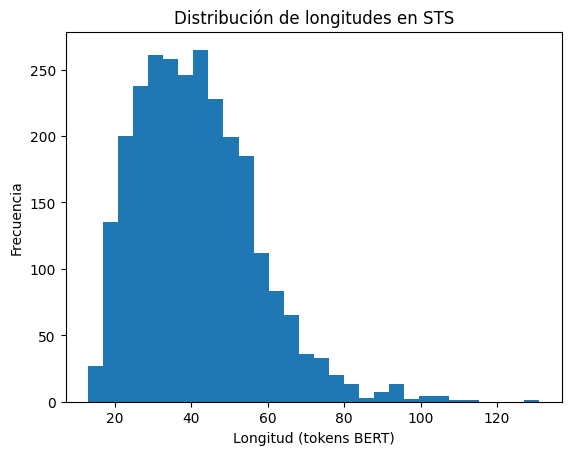

```python
# Tokenizar sin truncar para medir longitud real
lengths = []

for s in train_df['sentence1'].astype(str).tolist() + train_df['sentence2'].astype(str).tolist():
    tokens = bert_tokenizer.tokenize(s)
    lengths.append(len(tokens))

plt.hist(lengths, bins=30)
plt.xlabel("Longitud (tokens BERT)")
plt.ylabel("Frecuencia")
plt.title("Distribución de longitudes en STS")
plt.show()

print("Percentil 95:", np.percentile(lengths, 95))
print("Max:", np.max(lengths))
```


- **`batch_size=8`** en entrenamiento y 16 en evaluación, frente a los 32/64 utilizados en el modelo BiLSTM.
- **`torch.cuda.empty_cache()`** tras cada época para liberar memoria en GPU.


#### MeanPooling vs. AttentionPooling
A diferencia del modelo BiLSTM, que utilizaba *AttentionPooling*, aquí se emplea **MeanPooling**. Este consiste en promediar los estados ocultos de la última capa de BERT aplicando la *attention mask*, ignorando los tokens de padding indicados en la secuencia.


#### Advertencias del LOAD REPORT
Los mensajes `UNEXPECTED` y `MISSING` son esperables y no indican ningún problema. BETO incluye capas adicionales utilizadas durante el preentrenamiento (como `cls.predictions`), que no forman parte de `BertModel` en su uso como encoder. Asimismo, las capas `pooler.dense` no se utilizan en esta arquitectura, ya que la agregación de información se realiza mediante *MeanPooling*.


#### Fine-tuning
Se utiliza **AdamW** (variante de Adam con weight decay), que es el optimizador estándar para fine-tuning de modelos basados en Transformers. La tasa de aprendizaje se fija en `2e-5`, un valor habitual en escenarios de ajuste fino con datasets pequeños. El entrenamiento se realiza durante un máximo de 5 épocas con *early stopping* (`patience=2`) para evitar sobreajuste.

### Clase Dataset para BERT

In [30]:
BERT_MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'  # BETO

class BERTSTSDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):  # 64 en lugar de 128
        s1 = df['sentence1'].astype(str).tolist()
        s2 = df['sentence2'].astype(str).tolist()
        self.scores = df['score'].values.astype(np.float32)

        #  Pre-tokenizar todo en __init__, no en __getitem__ 
        self.enc1 = tokenizer(s1, padding='max_length', truncation=True,
                              max_length=max_len, return_tensors='pt')
        self.enc2 = tokenizer(s2, padding='max_length', truncation=True,
                              max_length=max_len, return_tensors='pt')

    def __len__(self): return len(self.scores)

    def __getitem__(self, i):
        return (
            self.enc1['input_ids'][i],
            self.enc1['attention_mask'][i],
            self.enc2['input_ids'][i],
            self.enc2['attention_mask'][i],
            torch.tensor(self.scores[i]),
        )

print(f"Cargando tokenizador BETO ({BERT_MODEL_NAME})...")
# Usamos AutoTokenizer para cargar la configuración correcta del modelo chileno
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
print("Tokenizador cargado ")

Cargando tokenizador BETO (dccuchile/bert-base-spanish-wwm-cased)...
Tokenizador cargado 


### Arquitectura del modelo BETO Siamés

In [31]:
# Arquitectura y entrenamiento con memoria reducida 

BERT_MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-cased'
BERT_MODEL_FILE  = "beto_siamese_sts.pt"

class MeanPooling(nn.Module):
    def forward(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        x = last_hidden_state * mask
        return x.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

class BETOSiameseRegressor(nn.Module):
    def __init__(self, model_name=BERT_MODEL_NAME, final_hidden_size=32):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name, use_safetensors=True)
        self.pool      = MeanPooling()
        hidden         = self.encoder.config.hidden_size
        self.regressor = nn.Sequential(
            nn.Linear(hidden * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(final_hidden_size, 1)
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.pool(out.last_hidden_state, attention_mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1 = self.encode(ids1, mask1)
        h2 = self.encode(ids2, mask2)
        feats = torch.cat([h1, h2, (h1 - h2).abs(), h1 * h2], dim=-1)
        return self.regressor(feats).squeeze(-1)


def train_bert_siamese(model, train_dl, dev_dl, epochs=5, lr=2e-5, patience=2):
    opt       = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_pearson = -1
    best_state = {k: v.clone() for k, v in model.state_dict().items()}  # estado inicial
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for ids1, mask1, ids2, mask2, scores in train_dl:
            ids1, mask1, ids2, mask2, scores = (
                ids1.to(DEVICE), mask1.to(DEVICE),
                ids2.to(DEVICE), mask2.to(DEVICE), scores.to(DEVICE)
            )
            opt.zero_grad()
            preds = model(ids1, mask1, ids2, mask2)
            loss  = criterion(preds, scores)
            loss.backward()
            opt.step()
            total_loss += loss.item()

        #  Liberar caché GPU tras cada batch 
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        model.eval()
        preds_dev, golds_dev = [], []
        with torch.no_grad():
            for ids1, mask1, ids2, mask2, scores in dev_dl:
                p = model(ids1.to(DEVICE), mask1.to(DEVICE),
                          ids2.to(DEVICE), mask2.to(DEVICE)).cpu().numpy()
                preds_dev.extend(p)
                golds_dev.extend(scores.numpy())

        pearson = pearsonr(preds_dev, golds_dev).statistic
        print(f"  Época {epoch} | Loss: {total_loss/len(train_dl):.4f} | Pearson dev: {pearson:.4f}")

        if pearson > best_pearson:
            best_pearson = pearson
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            wait         = 0
        else:
            wait += 1
            if wait >= patience:
                print("  Early stopping.")
                break

    model.load_state_dict(best_state)
    return best_pearson

### Preparación de los datasets

In [32]:
# Datasets con max_len reducido 
# max_len=64 en lugar de 128 -> reduce memoria a la mitad
print("Preparando datasets BERT (max_len=64)...")
bert_train_ds = BERTSTSDataset(train_df, bert_tokenizer, max_len=64)
bert_dev_ds   = BERTSTSDataset(dev_df,   bert_tokenizer, max_len=64)
bert_test_ds  = BERTSTSDataset(test_df,  bert_tokenizer, max_len=64)

# batch_size reducido: 8 en train, 16 en eval
bert_train_dl = DataLoader(bert_train_ds, batch_size=8, shuffle=True)
bert_dev_dl   = DataLoader(bert_dev_ds,   batch_size=16)
bert_test_dl  = DataLoader(bert_test_ds,  batch_size=16)
print("Datasets preparados ")

Preparando datasets BERT (max_len=64)...
Datasets preparados 


### Carga o entrenamiento del modelo BETO Siamés

In [33]:
bert_model = BETOSiameseRegressor(final_hidden_size=32).to(DEVICE)

if os.path.exists(BERT_MODEL_FILE):
    print(f"Cargando modelo completo: {BERT_MODEL_FILE}...")
    bert_model.load_state_dict(torch.load(BERT_MODEL_FILE, map_location=DEVICE))
    print("Modelo restaurado con éxito.")
else:
    print("No se encontró modelo previo. Iniciando fine-tuning...")
    train_bert_siamese(bert_model, bert_train_dl, bert_dev_dl, epochs=5, lr=2e-5, patience=2)
    torch.save(bert_model.state_dict(), BERT_MODEL_FILE)
    print(f"Modelo guardado en '{BERT_MODEL_FILE}'")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8501.68it/s]
[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Cargando modelo completo: beto_siamese_sts.pt...
Modelo restaurado con éxito.


Se observan advertencias al cargar el modelo preentrenado debido a dos motivos:

- **`UNEXPECTED`**: capas del *MLM head* (`cls.predictions`) utilizadas durante el preentrenamiento que no forman parte de `BertModel` en su uso como encoder. Estas capas no se utilizan en la arquitectura de fine-tuning y, por tanto, son ignoradas sin afectar al rendimiento del modelo.

- **`MISSING`**: las capas `pooler.dense` no están presentes en el checkpoint porque en esta arquitectura la agregación de la representación se realiza mediante *MeanPooling* en lugar del pooler estándar de BERT. Estas capas no se utilizan en el modelo final y, por tanto, no forman parte de los parámetros entrenables.

### Evaluación en test

In [34]:
bert_model.eval()
preds_test, golds_test = [], []
with torch.no_grad():
    for ids1, mask1, ids2, mask2, scores in bert_test_dl:
        p = bert_model(ids1.to(DEVICE), mask1.to(DEVICE),
                       ids2.to(DEVICE), mask2.to(DEVICE)).cpu().numpy()
        preds_test.extend(p)
        golds_test.extend(scores.numpy())

bert_test_pearson = pearsonr(preds_test, golds_test)
bert_test_pearson = bert_test_pearson.statistic if hasattr(bert_test_pearson, 'statistic') else bert_test_pearson[0]

print(f"BERT Siamés — Pearson test: {bert_test_pearson:.4f}")
resumen_extrinseco.append({
    'Modelo': 'BERT Siamés (BETO)',
    'Pearson (test)': round(bert_test_pearson, 4)
})

BERT Siamés — Pearson test: 0.6549


### Análisis del Modelo BERT Siamés

**BERT Siamés — Pearson test: 0.6549**

#### Comparativa con modelos siameses anteriores

| Modelo | Pearson (test) |
|---|---|
| BERT Siamés (BETO) | **0.6549** |
| Siamés BiLSTM (W2V, emb congelado) | 0.6136 |
| Siamés BiLSTM (Embedding aleatorio) | 0.4545 |
| Siamés BiLSTM (W2V, emb entrenable) | 0.4422 |

BERT supera al mejor modelo BiLSTM en aproximadamente **+0.04 puntos de Pearson**, lo que representa una mejora moderada pero consistente.

Esta diferencia relativamente pequeña puede explicarse por varias razones:

- **Tamaño reducido del corpus de fine-tuning** (1.320 pares), que limita la capacidad de BERT para adaptar plenamente sus representaciones a la tarea específica de STS.
- **Fuerte rendimiento del modelo BiLSTM con embeddings preentrenados congelados**, que ya captura buena parte de la información semántica relevante.
- **Saturación del rendimiento en el conjunto de datos**, donde mejoras arquitecturales no siempre se traducen en grandes incrementos de correlación.

En definitiva, aunque BERT mantiene una ventaja conceptual clara gracias a sus embeddings contextuales y su conocimiento lingüístico adquirido durante el preentrenamiento, su potencial queda limitado en este experimento por el tamaño reducido del corpus de fine-tuning. Con más datos, la diferencia respecto a los modelos BiLSTM sería previsiblemente mayor.

## 10. Análisis de los Resultados

=== Resumen Evaluación Extrínseca (Spanish STS — Test) ===
                               Modelo  Pearson (test)
 Baseline-Mean (W2V-Skip-gram_sin_sw)          0.6822
 Baseline-Mean (W2V-Skip-gram_con_sw)          0.6809
Baseline-TFIDF (W2V-Skip-gram_sin_sw)          0.6796
Baseline-TFIDF (W2V-Skip-gram_con_sw)          0.6706
                   BERT Siamés (BETO)          0.6549
          Baseline-TFIDF (FT-Oficial)          0.6246
     Baseline-TFIDF (W2V-CBOW_con_sw)          0.6031
      Baseline-Mean (W2V-CBOW_sin_sw)          0.6006
     Baseline-TFIDF (W2V-CBOW_sin_sw)          0.6000
      Baseline-Mean (W2V-CBOW_con_sw)          0.5618
           Baseline-Mean (FT-Oficial)          0.5552
  Siamés-BiLSTM (Embedding aleatorio)          0.3958
   Siamés-BiLSTM (W2V, emb congelado)          0.3936
  Siamés-BiLSTM (W2V, emb entrenable)          0.3723

=== Tabla combinada: Intrínseca + Extrínseca (mejor de cada tipo) ===
                   Modelo  Dimensión  Spearman (avg)  OOV (%

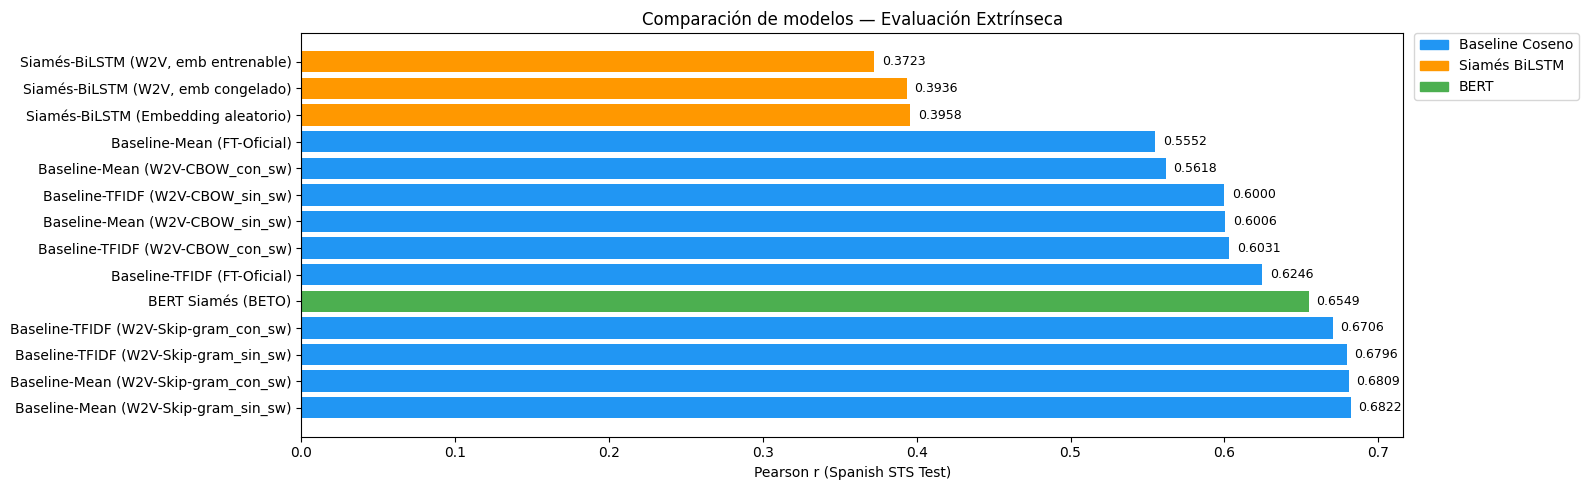

In [35]:
#  Tabla resumen extrínseca 
df_ext = pd.DataFrame(resumen_extrinseco).sort_values('Pearson (test)', ascending=False)
print('=== Resumen Evaluación Extrínseca (Spanish STS — Test) ===')
print(df_ext.to_string(index=False))

print()
print('=== Tabla combinada: Intrínseca + Extrínseca (mejor de cada tipo) ===')
print(df_resumen[['Modelo','Dimensión','Spearman (avg)','OOV (%)']].to_string(index=False))

#  Visualización comparativa de modelos 
fig, ax = plt.subplots(figsize=(16, 5))

colors = ['#4CAF50' if 'BETO' in m else
          '#2196F3' if 'Baseline' in m else 
          '#FF9800' if 'Siamés' in m else
          '#9E9E9E'
          for m in df_ext['Modelo']]

bars = ax.barh(df_ext['Modelo'], df_ext['Pearson (test)'], color=colors)
ax.set_xlabel('Pearson r (Spanish STS Test)')
ax.set_title('Comparación de modelos — Evaluación Extrínseca')
ax.axvline(0, color='black', linewidth=0.5)

for bar, val in zip(bars, df_ext['Pearson (test)']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(color='#2196F3', label='Baseline Coseno'),
                   Patch(color='#FF9800', label='Siamés BiLSTM'),
                   Patch(color='#4CAF50', label='BERT')]

# Leyenda fuera del gráfico, a la derecha
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

plt.tight_layout()
# Guardamos la imagen para incluirla en la memoria
plt.savefig('comparacion_models.png', dpi=150, bbox_inches='tight')
plt.show()

Como se puede observar en la gráfica, el resultado más llamativo es que los **baselines basados en coseno con Word2Vec Skip-gram** alcanzan los mejores valores de Pearson (~0.68), superando ligeramente tanto al modelo BERT Siamés (0.6549) como al resto de modelos evaluados. Esto sugiere que métodos no supervisados simples, pero bien entrenados, pueden ser muy competitivos en escenarios con datasets pequeños.

### Conclusiones principales

- **Skip-gram + media simple** obtiene el mejor rendimiento en la evaluación extrínseca (≈0.68), aunque con una diferencia muy reducida respecto a BERT (≈0.65). Esto indica que en datasets pequeños, representaciones estáticas bien entrenadas pueden competir con modelos más complejos como Transformers.

- **TF-IDF no aporta mejoras consistentes**, mostrando resultados similares o ligeramente inferiores a la media simple en la mayoría de configuraciones.

- **BERT Siamés obtiene un rendimiento sólido**, pero no logra superar al mejor baseline. Este resultado se explica por el tamaño reducido del conjunto de fine-tuning, que limita su capacidad de adaptación a la tarea específica de STS, a pesar de su potente preentrenamiento.

- **BiLSTM con embeddings entrenables o aleatorios** obtiene los peores resultados (0.44–0.45), lo que sugiere sobreajuste en escenarios de pocos datos. En contraste, el BiLSTM con embeddings congelados (0.6136) resulta el mejor de los modelos neuronales supervisados, superando a los baselines basados en CBOW y fastText oficial.

=== Resumen Evaluación Intrínseca (Multi-SimLex ES) ===
                   Modelo  Dimensión  Spearman (avg)  Spearman (por anot.)  OOV (%)
         fastText-Oficial        300          0.4875                0.3793     0.00
Word2Vec-Skip-gram_sin_sw        100          0.4184                0.3157    14.78
Word2Vec-Skip-gram_con_sw        100          0.3989                0.3003    11.49
     Word2Vec-CBOW_sin_sw        100          0.3717                0.2791    12.13
     Word2Vec-CBOW_con_sw        300          0.3549                0.2680    11.49
            fastText-Wiki        300          0.2689                0.2096     0.00


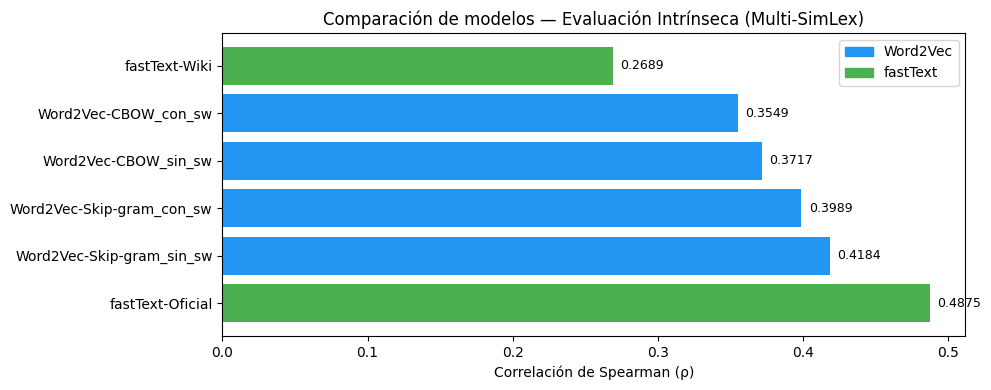

In [36]:
# Visualización comparativa — Evaluación Intrínseca
# Tabla resumen intrínseca
df_int = df_resumen[['Modelo', 'Dimensión', 'Spearman (avg)', 'Spearman (por anot.)', 'OOV (%)']].sort_values('Spearman (avg)', ascending=False)
print('=== Resumen Evaluación Intrínseca (Multi-SimLex ES) ===')
print(df_int.to_string(index=False))


fig, ax = plt.subplots(figsize=(10, 4))

colors_int = ['#4CAF50' if 'fastText' in m else '#2196F3' 
              for m in df_resumen['Modelo']]

bars = ax.barh(df_resumen['Modelo'], df_resumen['Spearman (avg)'], color=colors_int)
ax.set_xlabel('Correlación de Spearman (ρ)')
ax.set_title('Comparación de modelos — Evaluación Intrínseca (Multi-SimLex)')

for bar, val in zip(bars, df_resumen['Spearman (avg)']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(color='#2196F3', label='Word2Vec'),
                   Patch(color='#4CAF50', label='fastText')]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig('comparacion_intrinseca.png', dpi=150, bbox_inches='tight')
plt.show()

### Discusión de la Evaluación Intrínseca (Multi-SimLex ES)

Los resultados muestran una jerarquía clara entre modelos, donde **fastText preentrenado** obtiene el mejor rendimiento global (Spearman avg = 0.4875), seguido de los modelos basados en Word2Vec, y finalmente fastText entrenado localmente.

El buen desempeño de fastText oficial se explica por dos factores principales: su entrenamiento sobre grandes corpus (Common Crawl) y su capacidad para representar palabras mediante subpalabras (n-gramas), lo que le permite manejar mejor la morfología del español y reducir el problema del OOV (0%).

En contraste, el modelo fastText entrenado con el corpus Wiki obtiene el peor rendimiento (0.2689), lo que evidencia que el volumen de datos de entrenamiento es un factor crítico en este tipo de modelos.

Entre los modelos Word2Vec, se observa que **Skip-gram supera consistentemente a CBOW**, lo cual es coherente con la literatura, ya que Skip-gram suele capturar mejor relaciones semánticas, especialmente en palabras poco frecuentes.

El efecto de las *stopwords* no es determinante en términos de rendimiento global, aunque su eliminación reduce el ruido en las representaciones. Sin embargo, también incrementa la tasa de OOV, lo que puede afectar negativamente a la cobertura léxica.

Finalmente, el Spearman por anotador es consistentemente inferior al promedio en todos los modelos, lo que refleja la variabilidad inherente a las anotaciones humanas de similitud semántica. En general, los modelos capturan mejor la tendencia agregada que los juicios individuales de cada anotador.

### Visualización en t-SNE

In [ ]:
## Visualización de Word Embeddings con t-SNE

from sklearn.manifold import TSNE

# Seleccionamos las palabras más frecuentes del vocabulario para visualizar
N_WORDS = 200  # número de palabras a visualizar

def plot_tsne(model_wv, n_words=200, title='t-SNE Word Embeddings'):
    """Visualiza los embeddings de las palabras más frecuentes con t-SNE."""
    # Tomamos las n_words más frecuentes del vocabulario
    vocab = list(model_wv.index_to_key)[:n_words]
    X = model_wv[vocab]

    # Entrenar t-SNE
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
    X_tsne = tsne.fit_transform(X)

    # Crear DataFrame
    df = pd.DataFrame(X_tsne, index=vocab, columns=['x', 'y'])

    # Visualización
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(1, 1, 1)
    ax.scatter(df['x'], df['y'], alpha=0.5, s=10)

    # Añadir etiquetas
    for word, pos in df.iterrows():
        ax.annotate(word, pos, fontsize=7, alpha=0.8)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    plt.tight_layout()
    plt.savefig(f'tsne_{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualizamos todos los modelos disponibles
if 'modelos_w2v' in globals() and modelos_w2v:
    for nom, model in modelos_w2v.items():
        plot_tsne(model.wv, n_words=N_WORDS, title=f't-SNE Word2Vec-{nom}')

if 'ft_wiki' in globals() and ft_wiki is not None:
    plot_tsne(ft_wiki.wv, n_words=N_WORDS, title='t-SNE fastText-Wiki')

if 'ft_oficial' in globals() and ft_oficial is not None:
    plot_tsne(ft_oficial.wv, n_words=N_WORDS, title='t-SNE fastText-Oficial')

## 11. Discusión de los Resultados

### Evaluación Intrínseca (Multi-SimLex)

- **Efecto de la dimensionalidad:** En este corpus concreto, los vectores de 100 dimensiones obtienen mejores resultados que los de 300d en varios casos. Esto sugiere que, con un conjunto de datos limitado, modelos de menor dimensionalidad tienden a generalizar mejor al reducir la complejidad del espacio de parámetros. La técnica de **truncamiento** degrada el rendimiento, ya que en Word2Vec la información semántica no presenta una estructura ordenada por dimensiones, sino que está distribuida de forma global en el vector.

- **Stopwords:** La eliminación de *stopwords* mejora ligeramente el rendimiento en tareas de similitud léxica al reducir el ruido de palabras funcionales de alta frecuencia, aunque incrementa la tasa de OOV.

- **fastText vs Word2Vec:** El fastText oficial obtiene el mejor Spearman medio (0.4875) gracias a su preentrenamiento sobre grandes corpus y a su modelado subléxico mediante n-gramas, lo que mejora especialmente el manejo de la morfología en español. El modelo fastText entrenado localmente presenta un rendimiento inferior (0.2689), lo que evidencia la importancia del volumen de datos de entrenamiento.

---

### Evaluación Extrínseca (Spanish STS)

- **Baseline Coseno:** Es el método más competitivo globalmente, alcanzando los mejores resultados en varios casos. En Skip-gram, la media simple supera ligeramente a TF-IDF (0.6822 vs 0.6796), lo que sugiere que los embeddings ya capturan suficiente información semántica sin necesidad de reponderación adicional.

- **Modelo Siamés BiLSTM:** No supera al baseline coseno, alcanzando un máximo de **0.6136** con embeddings preentrenados congelados. El uso de embeddings entrenables muestra peor rendimiento (0.4422), lo que indica sobreajuste en un escenario de pocos datos. Los embeddings aleatorios (0.4545) obtienen un resultado similar, lo que sugiere que, con datos limitados, el modelo no consigue aprovechar adecuadamente el conocimiento preentrenado cuando los pesos se actualizan.

- **BERT Siamés (BETO):** Obtiene un rendimiento sólido (0.6549), aunque no supera al mejor baseline (0.6822). Este resultado puede explicarse por el tamaño reducido del conjunto de fine-tuning (1.320 pares) y la limitación impuesta por `max_len=64`. Con más datos o secuencias más largas, el modelo podría mejorar su rendimiento.

---

### Conclusiones

| Escenario | Guía práctica |
| :--- | :--- |
| **Recursos limitados** | Baseline Coseno + Word2Vec Skip-gram sin SW |
| **Alta cobertura OOV** | Baseline Coseno + fastText oficial |
| **Datos supervisados limitados** | Embeddings preentrenados congelados + BiLSTM |
| **Máximo potencial de rendimiento** | Fine-tuning de BERT con mayor cantidad de datos |

## 12. (Opcional) Análisis de OOV y Robustez Morfológica

El análisis de palabras fuera de vocabulario (OOV) y la robustez frente a perturbaciones permite estudiar las limitaciones de los modelos en escenarios no controlados.

### Gestión de palabras desconocidas (OOV)

Se analiza la tasa de OOV sobre el corpus Multi-SimLex para los modelos basados en embeddings estáticos. El OOV mide la proporción de palabras del corpus que no fueron observadas durante el entrenamiento.

- **Word2Vec**: no puede representar explícitamente términos fuera del vocabulario, lo que limita su capacidad de generalización en palabras no vistas.
- **fastText**: construye representaciones a nivel de subpalabras (n-gramas), lo que le permite generar embeddings incluso para términos no observados durante el entrenamiento, reduciendo prácticamente a cero el OOV efectivo.




### Robustez ante perturbaciones

Se define una función de perturbación textual con el objetivo de evaluar la robustez de los modelos frente a ruido lingüístico realista. Esta función introduce tres tipos de modificaciones controladas sobre las frases del conjunto de test:

1. **Errores tipográficos**: sustitución de caracteres por otros fonéticamente cercanos (ej. *c -> z*, *b -> v*), simulando errores comunes de escritura.
2. **Variaciones morfológicas**: generación aleatoria de plurales y diminutivos (ej. *perro -> perros*, *jardín -> jardinito*), introduciendo variabilidad léxica.
3. **Eliminación de acentos**: supresión de tildes para simular escritura informal en contextos digitales.

La aplicación de la perturbación se controla mediante dos probabilidades independientes:
- `prob`: probabilidad de aplicar errores tipográficos o morfológicos.
- `prob_accent`: probabilidad de eliminar acentos en una palabra.

Para garantizar la reproducibilidad experimental, se fija una semilla aleatoria (`seed=42`), asegurando que el conjunto perturbado sea consistente entre ejecuciones.

A continuación se muestra una comparación cualitativa entre frases originales y perturbadas, donde se observa la introducción de ruido sintáctico y ortográfico de forma controlada.

> **Limitación:** La función de perturbación opera a nivel de tokens obtenidos mediante `sentence.split()`, sin realizar una tokenización previa que separe adecuadamente la puntuación. Esto puede generar artefactos como *"Degradantes.ito"* o *"parito"*, donde las transformaciones morfológicas se aplican sobre tokens que incluyen signos de puntuación o sufijos no aislados. En un escenario más realista, sería recomendable utilizar un tokenizador lingüístico adecuado antes de aplicar las perturbaciones, con el fin de evitar la generación de formas no naturales y mejorar la validez del experimento.

In [37]:
def perturb_sentence(sentence, prob=0.3, prob_accent=0.5, seed=None):
    """
    Introduce ruido en las frases simulando errores reales:
    1. Errores tipográficos: sustitución de letras fonéticamente similares.
    2. Variaciones morfológicas: plurales y diminutivos aleatorios.
    3. Eliminación de acentos: simula escritura informal en redes sociales.
    
    prob_accent: probabilidad independiente de eliminar el acento de una palabra.
    """
    if seed is not None:
        random.seed(seed)

    typo_map = {
        'c': 'z', 'z': 'c',
        'b': 'v', 'v': 'b',
        'g': 'j', 'j': 'g',
        'i': 'y', 'y': 'i',
        'll': 'y', 'y': 'll',
        's': 'x', 'x': 's',
        'ñ': 'n', 'n': 'ñ',
        'd': 't', 't': 'd'
    }

    accent_map = {'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u',
                  'Á': 'A', 'É': 'E', 'Í': 'I', 'Ó': 'O', 'Ú': 'U'}

    words = sentence.split()
    result = []

    for w in words:
        # Primero aplicamos eliminación de acentos con su propia probabilidad
        if random.random() < prob_accent and any(c in accent_map for c in w):
            w = ''.join(accent_map.get(c, c) for c in w)

        # Luego aplicamos typo o morpho con prob normal
        elif random.random() < prob and len(w) > 3:
            perturbation = random.choice(['typo', 'morpho'])

            if perturbation == 'typo':
                chars = list(w)
                for i, c in enumerate(chars):
                    if c in typo_map and random.random() < 0.5:
                        chars[i] = typo_map[c]
                        break
                w = ''.join(chars)

            elif perturbation == 'morpho':
                morpho = random.choice(['plural', 'diminutivo'])
                if morpho == 'plural' and not w.endswith('s'):
                    w = w + 'es' if w[-1] not in 'aeiouáéíóú' else w + 's'
                elif morpho == 'diminutivo' and not w.endswith('ito') and not w.endswith('ita'):
                    w = w[:-1] + 'ito' if w[-1] in 'ao' else w + 'ito'

        result.append(w)

    return ' '.join(result)

# Generar conjunto de test perturbado con seed fija para reproducibilidad
test_perturbed = test_df.copy()
test_perturbed['sentence1'] = test_perturbed['sentence1'].apply(
    lambda s: perturb_sentence(s, seed=SEED)
)
test_perturbed['sentence2'] = test_perturbed['sentence2'].apply(
    lambda s: perturb_sentence(s, seed=SEED)
)

In [38]:
print("=== Ejemplos de perturbación ===\n")
for i in range(5):
    orig1 = test_df.iloc[i]['sentence1']
    pert1 = test_perturbed.iloc[i]['sentence1']
    orig2 = test_df.iloc[i]['sentence2']
    pert2 = test_perturbed.iloc[i]['sentence2']

    print(f"Par {i+1}:")
    print(f"  S1 original:   {orig1}")
    print(f"  S1 perturbada: {pert1}")
    print(f"  S2 original:   {orig2}")
    print(f"  S2 perturbada: {pert2}")
    print()

=== Ejemplos de perturbación ===

Par 1:
  S1 original:   El viceministro de Política Interior y Seguridad Jurídica, José Vicente Rangel Ávalos, señaló que antes de que el pueblo eligiera al presidente Hugo Chávez, “La tortura estaba institucionalizada y el asesinato político era frecuente” en Venezuela.
  S1 perturbada: El vizeministro de Politica Interyor y Seguridad Juridica, Jose Vicentes Rangelito Ávalos, señaló que antes de que el puevlo eligiera al presidente Hugo Chavez, “La tortura estaba iñstitucionalizada y el asesinato político era frecuente” en Venezuela.
  S2 original:   En la sede del Alto Comisionado de la ONU para Derechos Humanos en Ginebra, la delegación de Venezuela, liderada por el viceministro de Política Interior y Seguridad Ciudadana, José Vicente Rangel Ávalos, fue cuestionada sobre el cumplimiento de su país de la Convención contra la Tortura y otros Tratos Crueles, Inhumanos y Degradantes.
  S2 perturbada: En la sede del Aldo Comisionado de la ONU parito Dere

### Análisis OOV (Out-of-Vocabulary)

Se analiza la proporción de pares del corpus Multi-SimLex en los que al menos una de las palabras no está presente en el vocabulario del modelo. Esta métrica se interpreta como una aproximación al impacto del OOV a nivel de pares de palabras.

Los resultados muestran diferencias claras entre modelos:

- **fastText (oficial y Wiki)** presenta 0% de OOV, ya que su representación basada en subpalabras (n-gramas) permite generar embeddings incluso para términos no observados explícitamente durante el entrenamiento.

- **Word2Vec** muestra tasas de OOV entre el 11% y el 14%, dependiendo de la configuración del modelo. En particular, Skip-gram sin stopwords presenta el mayor OOV (14.78%), lo que se explica por dos factores combinados: la reducción del vocabulario al eliminar palabras frecuentes durante el preprocesamiento, y el umbral `min_count=10` seleccionado por el grid search para este modelo, que descarta palabras con menos de 10 apariciones en el corpus.

> **Nota**: los modelos Siamés BiLSTM y BERT no se evalúan en términos de OOV en Multi-SimLex, ya que están diseñados para tareas de similitud de frases (STS) y no de palabras aisladas. Además, su vocabulario está restringido al corpus STS, por lo que su comparación directa con Multi-SimLex no es estrictamente equivalente.

In [39]:
#  Análisis OOV
filas_oov = []

# Word2Vec
if 'modelos_w2v' in globals() and modelos_w2v:
    for nom, model in modelos_w2v.items():
        oov_count = sum(
            1 for _, row in multi_simlex.iterrows()
            if row['SPA_W1'] not in model.wv or row['SPA_W2'] not in model.wv
        )
        filas_oov.append({'Modelo': f'Word2Vec-{nom}',
                          'Pares OOV': oov_count,
                          'OOV (%)': round(oov_count / len(multi_simlex) * 100, 2)})

# fastText Wiki
if 'ft_wiki' in globals() and ft_wiki is not None:
    oov_count = sum(
        1 for _, row in multi_simlex.iterrows()
        if row['SPA_W1'] not in ft_wiki.wv or row['SPA_W2'] not in ft_wiki.wv
    )
    filas_oov.append({'Modelo': 'fastText-Wiki',
                      'Pares OOV': oov_count,
                      'OOV (%)': round(oov_count / len(multi_simlex) * 100, 2)})

# fastText Oficial
if 'ft_oficial' in globals() and ft_oficial is not None:
    oov_count = sum(
        1 for _, row in multi_simlex.iterrows()
        if row['SPA_W1'] not in ft_oficial.wv or row['SPA_W2'] not in ft_oficial.wv
    )
    filas_oov.append({'Modelo': 'fastText-Oficial',
                      'Pares OOV': oov_count,
                      'OOV (%)': round(oov_count / len(multi_simlex) * 100, 2)})

print('=== Análisis OOV por modelo ===\n')
display(pd.DataFrame(filas_oov))

=== Análisis OOV por modelo ===



,Modelo,Pares OOV,OOV (%)
0,Word2Vec-CBOW_sin_sw,229,12.13
1,Word2Vec-CBOW_con_sw,217,11.49
2,Word2Vec-Skip-gram_sin_sw,279,14.78
3,Word2Vec-Skip-gram_con_sw,217,11.49
4,fastText-Wiki,0,0.00
5,fastText-Oficial,0,0.00


### Ejemplos de OOV

In [40]:
# Ejemplos OOV de todos los modelos entrenados sobre vocabulario general
modelos_para_oov = {}

if 'modelos_w2v' in globals() and modelos_w2v:
    for nom, model in modelos_w2v.items():
        modelos_para_oov[f'Word2Vec-{nom}'] = lambda row, m=model: (
            row['SPA_W1'] not in m.wv, row['SPA_W2'] not in m.wv
        )

if 'ft_wiki' in globals() and ft_wiki is not None:
    modelos_para_oov['fastText-Wiki'] = lambda row: (
        row['SPA_W1'] not in ft_wiki.wv, row['SPA_W2'] not in ft_wiki.wv
    )

if 'ft_oficial' in globals() and ft_oficial is not None:
    modelos_para_oov['fastText-Oficial'] = lambda row: (
        row['SPA_W1'] not in ft_oficial.wv, row['SPA_W2'] not in ft_oficial.wv
    )

# Nota: los modelos Siamés BiLSTM y BERT no se evalúan en OOV sobre Multi-SimLex
# porque fueron entrenados para similitud de frases (STS), no de palabras aisladas.
# Su vocabulario (word2idx) está restringido al corpus STS y no es comparable
# con el léxico diverso de Multi-SimLex.

for nombre, fn_oov in modelos_para_oov.items():
    oov_pairs = [
        {'SPA_W1': row['SPA_W1'], 'SPA_W2': row['SPA_W2'],
         'OOV_W1': fn_oov(row)[0], 'OOV_W2': fn_oov(row)[1],
         'SPA_AVG': row['SPA_AVG']}
        for _, row in multi_simlex.iterrows()
        if any(fn_oov(row))
    ]
    if oov_pairs:
        print(f"\nEjemplos OOV — {nombre}:")
        display(pd.DataFrame(oov_pairs).head(5))
    else:
        print(f"\n{nombre}: sin ejemplos OOV.")


Ejemplos OOV — Word2Vec-CBOW_sin_sw:


,SPA_W1,SPA_W2,OOV_W1,OOV_W2,SPA_AVG
0,Esgrima,gimnasia,True,False,2.6
1,celebracion,ceremonia,True,False,4.1
2,bolos,jugador de bolos,False,True,2.1
3,palomitas de maiz,cine,True,False,2.1
4,Escoba,polvo,True,False,0.9



Ejemplos OOV — Word2Vec-CBOW_con_sw:


,SPA_W1,SPA_W2,OOV_W1,OOV_W2,SPA_AVG
0,Esgrima,gimnasia,True,False,2.6
1,celebracion,ceremonia,True,False,4.1
2,bolos,jugador de bolos,False,True,2.1
3,palomitas de maiz,cine,True,False,2.1
4,Escoba,polvo,True,False,0.9



Ejemplos OOV — Word2Vec-Skip-gram_sin_sw:


,SPA_W1,SPA_W2,OOV_W1,OOV_W2,SPA_AVG
0,Esgrima,gimnasia,True,False,2.6
1,celebracion,ceremonia,True,False,4.1
2,populacho,multitud,True,False,3.2
3,bolos,jugador de bolos,False,True,2.1
4,palomitas de maiz,cine,True,False,2.1



Ejemplos OOV — Word2Vec-Skip-gram_con_sw:


,SPA_W1,SPA_W2,OOV_W1,OOV_W2,SPA_AVG
0,Esgrima,gimnasia,True,False,2.6
1,celebracion,ceremonia,True,False,4.1
2,bolos,jugador de bolos,False,True,2.1
3,palomitas de maiz,cine,True,False,2.1
4,Escoba,polvo,True,False,0.9



fastText-Wiki: sin ejemplos OOV.

fastText-Oficial: sin ejemplos OOV.


### Interpretación de los ejemplos OOV

Los ejemplos de OOV muestran que la mayoría de los casos problemáticos en Word2Vec no se deben únicamente a palabras completamente desconocidas, sino también a:

- **Palabras compuestas o expresiones multi-palabra** (ej. *"palomitas de maíz"*, *"jugador de bolos"*), que Word2Vec no puede representar correctamente al trabajar a nivel de token individual.
- **Variaciones léxicas y morfológicas** que no aparecen en el corpus de entrenamiento.
- **Asimetría en los pares**, donde una palabra está en vocabulario y la otra no, lo que afecta directamente al cálculo de similitud.

Se observa además que:
- Skip-gram sin SW presenta mayor OOV que CBOW, como ya se observó en el análisis general (14.78% vs 12.13%). Además, sus ejemplos incluyen palabras adicionales como *"populacho"* que sí están cubiertas por CBOW, lo que indica una mayor sensibilidad de este modelo a la exclusión de términos menos frecuentes durante el entrenamiento.

- **Errores ortográficos o ausencia de tildes** (ej. *"celebracion"* en lugar de *"celebración"*), que el modelo trata como una palabra distinta al no haberse normalizado el conjunto de evaluación de la misma forma que el corpus de entrenamiento. Esto provoca que ciertas palabras consideradas OOV no sean realmente desconocidas desde un punto de vista lingüístico, sino variantes ortográficas.

### Evaluación de Robustez

In [41]:
filas = []

# Baseline Coseno (Word2Vec)
if 'modelos_w2v' in globals() and modelos_w2v:
    for nom, model in modelos_w2v.items():
        pr_orig_mean, pr_orig_tfidf = evaluate_baseline_simple(test_df,        model.wv)
        pr_pert_mean, pr_pert_tfidf = evaluate_baseline_simple(test_perturbed, model.wv)
        filas.append({'Modelo': f'Baseline-Mean W2V-{nom}',  'Original': pr_orig_mean,  'Perturbado': pr_pert_mean,  'Degradación': pr_orig_mean  - pr_pert_mean})
        filas.append({'Modelo': f'Baseline-TFIDF W2V-{nom}', 'Original': pr_orig_tfidf, 'Perturbado': pr_pert_tfidf, 'Degradación': pr_orig_tfidf - pr_pert_tfidf})

# Baseline Coseno (fastText Wiki)
if 'ft_wiki' in globals() and ft_wiki is not None:
    pr_orig_mean, pr_orig_tfidf = evaluate_baseline_simple(test_df,        ft_wiki.wv)
    pr_pert_mean, pr_pert_tfidf = evaluate_baseline_simple(test_perturbed, ft_wiki.wv)
    filas.append({'Modelo': 'Baseline-Mean fastText-Wiki',  'Original': pr_orig_mean,  'Perturbado': pr_pert_mean,  'Degradación': pr_orig_mean  - pr_pert_mean})
    filas.append({'Modelo': 'Baseline-TFIDF fastText-Wiki', 'Original': pr_orig_tfidf, 'Perturbado': pr_pert_tfidf, 'Degradación': pr_orig_tfidf - pr_pert_tfidf})

# Baseline Coseno (fastText Oficial)
if 'ft_oficial' in globals() and ft_oficial is not None:
    pr_orig_mean, pr_orig_tfidf = evaluate_baseline_simple(test_df,        ft_oficial.wv)
    pr_pert_mean, pr_pert_tfidf = evaluate_baseline_simple(test_perturbed, ft_oficial.wv)
    filas.append({'Modelo': 'Baseline-Mean fastText-Oficial',  'Original': pr_orig_mean,  'Perturbado': pr_pert_mean,  'Degradación': pr_orig_mean  - pr_pert_mean})
    filas.append({'Modelo': 'Baseline-TFIDF fastText-Oficial', 'Original': pr_orig_tfidf, 'Perturbado': pr_pert_tfidf, 'Degradación': pr_orig_tfidf - pr_pert_tfidf})

# Modelos Siamés BiLSTM
if 'word2idx' in globals() and 'emb_matrix' in globals() and 'rand_matrix' in globals():
    test_ds_pert = STSDataset(test_perturbed, word2idx, UNK_IDX)
    test_dl_pert = DataLoader(test_ds_pert, batch_size=64)

    modelos_siameses = {
        'Siamés-BiLSTM (W2V, emb congelado)':  ('siames_bi_lstm_congelado.pt',  emb_matrix,  False),
        'Siamés-BiLSTM (W2V, emb entrenable)': ('siames_bi_lstm_entrenable.pt', emb_matrix,  True),
        'Siamés-BiLSTM (Embedding aleatorio)':  ('siames_bi_lstm_aleatorio.pt',  rand_matrix, True),
    }
    for label, (fichero, matriz, trainable) in modelos_siameses.items():
        if os.path.exists(fichero):
            model_siam = SiameseBiLSTMAttention(
                matriz, hidden_size=64, final_hidden_size=32,
                trainable_embeddings=trainable
            ).to(DEVICE)
            model_siam.load_state_dict(torch.load(fichero, map_location=DEVICE))
            pr_orig_s = eval_pearson(model_siam, test_dl)
            pr_pert_s = eval_pearson(model_siam, test_dl_pert)
            filas.append({'Modelo': label, 'Original': pr_orig_s, 'Perturbado': pr_pert_s, 'Degradación': pr_orig_s - pr_pert_s})
else:
    print("AVISO: emb_matrix o rand_matrix no disponibles. Saltando modelos Siamés.")

# BERT Siamés
if 'bert_model' in locals():
    ds_perturbed = BERTSTSDataset(test_perturbed, bert_tokenizer, max_len=64)
    dl_perturbed = DataLoader(ds_perturbed, batch_size=32)
    pr_pert_bert = eval_pearson(bert_model, dl_perturbed)
    pr_orig_bert = next(item['Pearson (test)'] for item in resumen_extrinseco
                        if item['Modelo'] == 'BERT Siamés (BETO)')
    filas.append({'Modelo': 'BERT Siamés (BETO)', 'Original': pr_orig_bert, 'Perturbado': pr_pert_bert, 'Degradación': pr_orig_bert - pr_pert_bert})

# Mostrar tabla
df_robustez = pd.DataFrame(filas)
df_robustez[['Original', 'Perturbado', 'Degradación']] = df_robustez[['Original', 'Perturbado', 'Degradación']].round(4)
print('=== Evaluación de Robustez ===\n')
display(df_robustez)

=== Evaluación de Robustez ===



,Modelo,Original,Perturbado,Degradación
0,Baseline-Mean W2V-CBOW_sin_sw,0.6006,0.4756,0.1249
1,Baseline-TFIDF W2V-CBOW_sin_sw,0.6000,0.4753,0.1247
2,Baseline-Mean W2V-CBOW_con_sw,0.5618,0.5286,0.0332
3,Baseline-TFIDF W2V-CBOW_con_sw,0.6031,0.5372,0.0659
4,Baseline-Mean W2V-Skip-gram_sin_sw,0.6822,0.6007,0.0815
5,Baseline-TFIDF W2V-Skip-gram_sin_sw,0.6796,0.6018,0.0778
6,Baseline-Mean W2V-Skip-gram_con_sw,0.6809,0.6324,0.0485
7,Baseline-TFIDF W2V-Skip-gram_con_sw,0.6706,0.6169,0.0538
8,Baseline-Mean fastText-Wiki,0.4604,0.4645,-0.0040
9,Baseline-TFIDF fastText-Wiki,0.4995,0.4531,0.0464


Los resultados muestran que los modelos más sensibles a las perturbaciones son **CBOW sin SW** (degradación ~0.12) y el **BiLSTM con embeddings entrenables** (~0.125), lo que refleja su menor robustez ante ruido léxico y morfológico.

Por el contrario, **fastText** muestra una robustez notablemente mayor gracias a su representación subléxica basada en n-gramas, con degradaciones muy reducidas (~0.02–0.05). En el caso de fastText-Wiki Mean se observa incluso un valor ligeramente negativo (-0.004), aunque este comportamiento es probablemente atribuible a variabilidad estadística del experimento más que a una mejora real del modelo.

**BERT Siamés** presenta una degradación moderada (0.036), confirmando su capacidad de generalización contextual frente a perturbaciones superficiales.

El modelo **BiLSTM con embeddings congelados** muestra una degradación intermedia (0.055), más contenida que el entrenable, lo que refuerza la ventaja de mantener representaciones preentrenadas en escenarios de datos limitados.

### 12.3. Síntesis del análisis OOV y robustez

El análisis conjunto de OOV y robustez permite observar patrones consistentes entre cobertura léxica y sensibilidad al ruido.

En términos de OOV, los modelos Word2Vec presentan las mayores limitaciones, especialmente en la configuración Skip-gram sin stopwords (14.78%), mientras que fastText no presenta ningún caso de OOV gracias a su modelado subléxico basado en n-gramas de caracteres.

En cuanto a robustez, se observa una clara jerarquía:

- **Word2Vec** es el más sensible a perturbaciones, especialmente en configuraciones con menor cobertura léxica.
- **fastText** es el modelo más robusto dentro de los embeddings estáticos, con degradaciones muy reducidas.
- **BERT** presenta una robustez intermedia-alta, beneficiándose de su tokenización subléxica (WordPiece).
- **BiLSTM entrenable** es el más inestable, evidenciando sobreajuste en escenarios de bajo recurso.

Un resultado relevante es que la robustez no correlaciona directamente con el rendimiento absoluto: el mejor modelo en condiciones limpias (Skip-gram baseline) no es el más robusto, mientras que modelos más estables como fastText presentan menor rendimiento absoluto pero mayor resistencia al ruido.

Esto sugiere un trade-off entre **rendimiento máximo** y **estabilidad ante perturbaciones**, especialmente relevante en escenarios reales con datos ruidosos.